
=== Phase-1: Realism + Baselines ===
Random seed: 42 | FAST_DEMO=False | Attacker mode=random

[Small] Build twin & stats

[Small] Network Stats
Nodes: 6 | Edges: 6 | Avg degree: 2.00

=== CVE/CVSS Vulnerability Model Summary ===
Services present: auth_service, dbms, file_share, reverse_proxy, web_app

Service → example CVE and aggregated p_service:
  auth_service      top=CVE-2021-44228  base=10.0  expl=3.9  p_service≈0.623
  dbms              top=CVE-2021-44228  base=10.0  expl=3.9  p_service≈0.623
  file_share        top=CVE-2020-0796  base=10.0  expl=3.9  p_service≈0.583
  reverse_proxy     top=CVE-2023-25690  base=9.8  expl=3.9  p_service≈0.512
  web_app           top=CVE-2023-28432  base=8.8  expl=3.9  p_service≈0.553

Sample of 6 edges with p_compromise:
  AppServerA -> InternalSwitch   action=cred_theft  role_v=internal   svcs=['file_share']  | CVE-BASED  p≈0.609
  LoadBalancer -> AppServerA       action=lateral     role_v=app        svcs=['web_app', 'auth_service']  | CVE-BAS

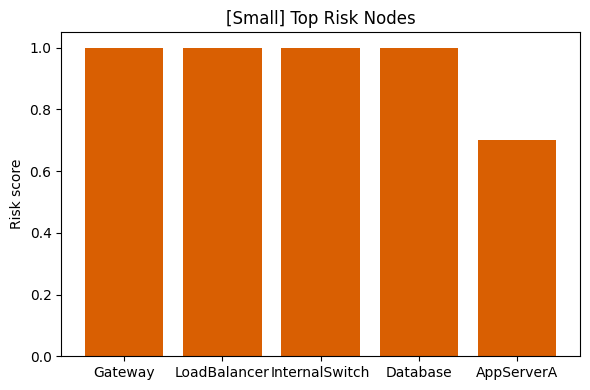

  [Saved] results/phase1_small_risk_heatmap.png


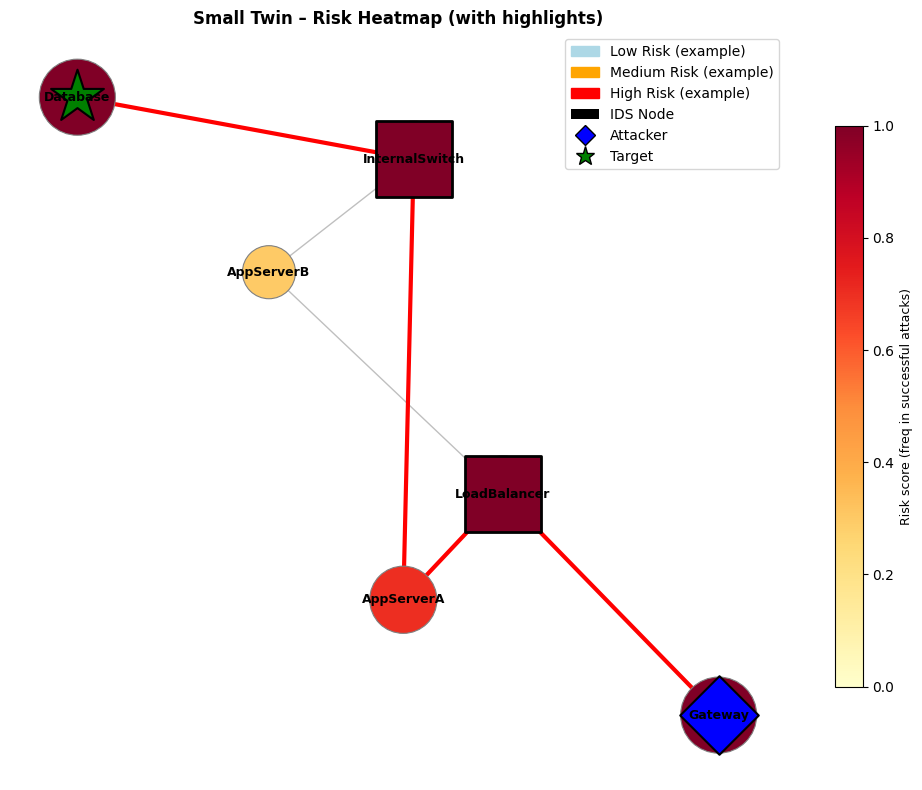

  [Saved] results/phase1_small_detection_vs_budget.png


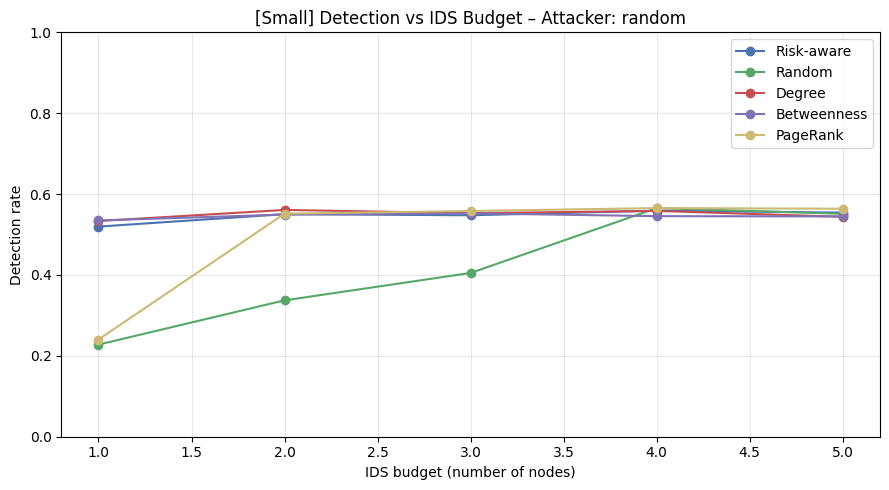


[Large] Build twin & stats

[Large] Network Stats
Nodes: 220 | Edges: 651 | Avg degree: 5.92

=== CVE/CVSS Vulnerability Model Summary ===
Services present: auth_service, dbms, file_share, ldap, reverse_proxy, ssh, web_app

Service → example CVE and aggregated p_service:
  auth_service      top=CVE-2021-44228  base=10.0  expl=3.9  p_service≈0.623
  dbms              top=CVE-2021-44228  base=10.0  expl=3.9  p_service≈0.623
  file_share        top=CVE-2020-0796  base=10.0  expl=3.9  p_service≈0.583
  ldap              top=CVE-2020-25692  base=8.8  expl=3.9  p_service≈0.481
  reverse_proxy     top=CVE-2023-25690  base=9.8  expl=3.9  p_service≈0.512
  ssh               top=CVE-2020-15778  base=7.8  expl=3.9  p_service≈0.450
  web_app           top=CVE-2023-28432  base=8.8  expl=3.9  p_service≈0.553

Sample of 8 edges with p_compromise:
  17 -> 65               action=lateral     role_v=internal   svcs=['file_share', 'ldap']  | CVE-BASED  p≈0.744
  194 -> 153              action=lateral   

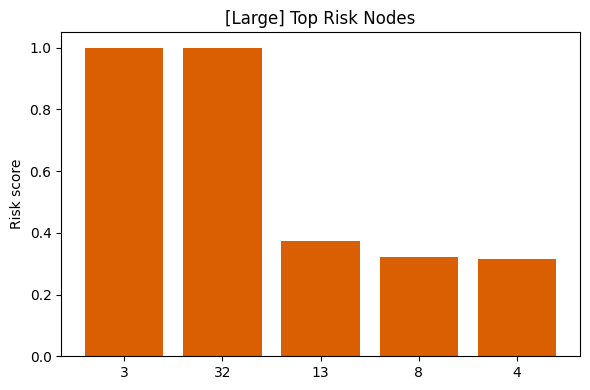

  [Saved] results/phase1_large_risk_heatmap.png


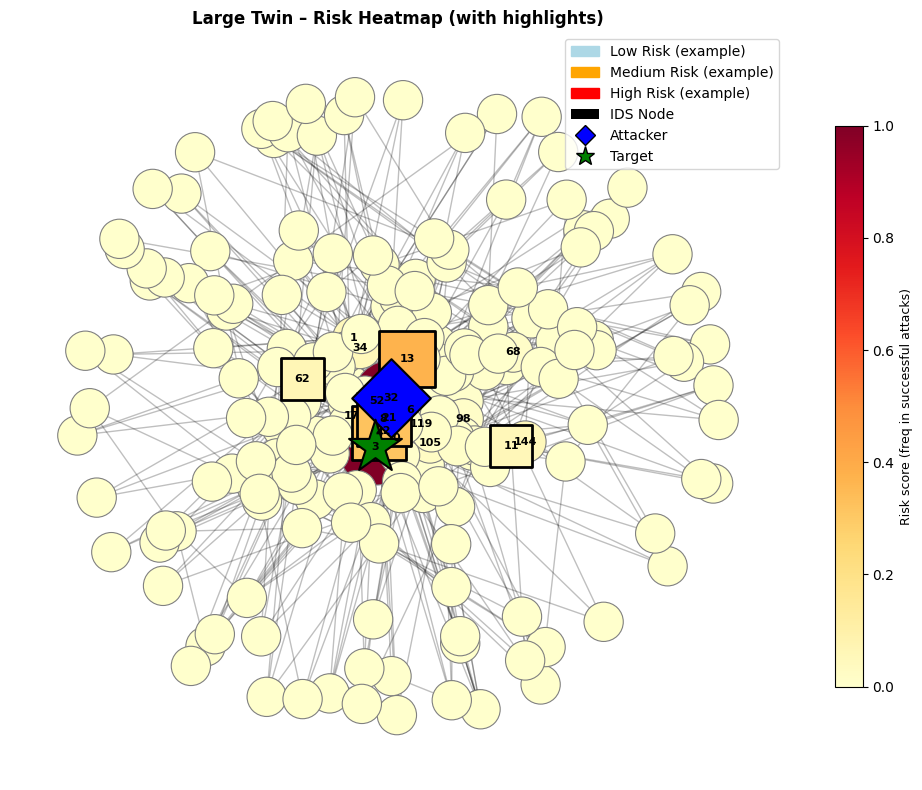

  [Saved] results/phase1_large_detection_vs_budget.png


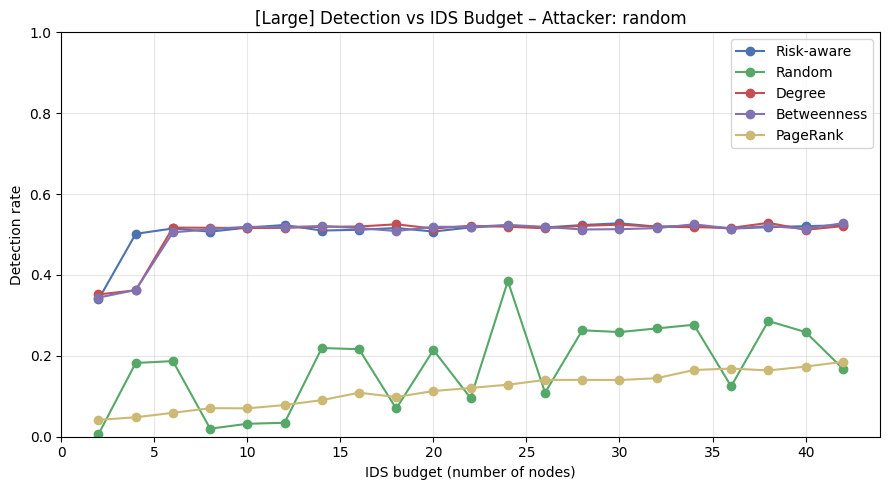

In [ ]:

# Phase-1: Realistic Vulnerabilities + Intelligent Attackers + Baselines (FIXED)


import os, random, time, math
from collections import Counter
from typing import Dict, List, Tuple, Set, Optional

import networkx as nx
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D


os.makedirs("results", exist_ok=True)


SEED = 42
random.seed(SEED)
plt.style.use("seaborn-v0_8-deep")

FAST_DEMO = False  # set True for quick iteration
NUM_ATTACKS_SMALL = 2000 if FAST_DEMO else 5000
NUM_ATTACKS_LARGE = 4000 if FAST_DEMO else 10000

MAX_STEPS_SMALL = 25
MAX_STEPS_LARGE = 50

LARGE_N = 120 if FAST_DEMO else 220
LARGE_M = 3
LARGE_TRIADIC_P = 0.2

# Node-budget baselines
IDS_BUDGET_SMALL = 2
IDS_BUDGET_LARGE_PCT = 0.02  # 2%

# Imperfect detection (false negatives)
P_DETECT_ON_IDS = 0.95

# Attacker options
ATTACKER_MODE = "random"   # "random" | "mpp" | "stealthy" | "noisy"

# Path listings
K_SHORTEST = 10
CUTOFF_SMALL = 6
CUTOFF_LARGE = 10


def safe_sample(population, k: int):

    if population is None:
        return []
    try:
        items = list(population)
    except TypeError:
        return []
    n = len(items)
    if n == 0 or k <= 0:
        return []
    k = min(k, n)
    random.shuffle(items)
    return items[:k]


CVE_CATALOG: Dict[str, List[Dict]] = {
    "reverse_proxy": [
        {"cve": "CVE-2023-25690", "cvss_base": 9.8, "exploitability": 3.9},
        {"cve": "CVE-2022-31813", "cvss_base": 7.5, "exploitability": 2.8},
    ],
    "web_app": [
        {"cve": "CVE-2023-28432", "cvss_base": 8.8, "exploitability": 3.9},
        {"cve": "CVE-2022-3602",  "cvss_base": 8.2, "exploitability": 3.9},
    ],
    "auth_service": [
        {"cve": "CVE-2023-23397", "cvss_base": 9.8, "exploitability": 3.9},
        {"cve": "CVE-2021-44228", "cvss_base": 10.0, "exploitability": 3.9},
    ],
    "dbms": [
        {"cve": "CVE-2022-21587", "cvss_base": 9.8, "exploitability": 3.9},
        {"cve": "CVE-2021-44228", "cvss_base": 10.0, "exploitability": 3.9},
    ],
    "cache": [
        {"cve": "CVE-2022-0543",  "cvss_base": 10.0, "exploitability": 3.9},
        {"cve": "CVE-2021-42306", "cvss_base": 7.5,  "exploitability": 2.8},
    ],
    "message_queue": [
        {"cve": "CVE-2022-33980", "cvss_base": 8.1, "exploitability": 3.9},
        {"cve": "CVE-2021-30116", "cvss_base": 7.5, "exploitability": 2.8},
    ],
    "file_share": [
        {"cve": "CVE-2020-0796", "cvss_base": 10.0, "exploitability": 3.9},
        {"cve": "CVE-2017-0144", "cvss_base": 8.1,  "exploitability": 3.9},
    ],
    "scada_gateway": [
        {"cve": "CVE-2022-26809", "cvss_base": 9.8, "exploitability": 3.9},
        {"cve": "CVE-2021-32934", "cvss_base": 8.8, "exploitability": 3.9},
    ],
    "smb": [
        {"cve": "CVE-2021-1675", "cvss_base": 7.5, "exploitability": 2.8},
        {"cve": "CVE-2017-0143", "cvss_base": 8.1, "exploitability": 3.9},
    ],
    "ssh": [
        {"cve": "CVE-2023-48795", "cvss_base": 7.5, "exploitability": 2.8},
        {"cve": "CVE-2020-15778", "cvss_base": 7.8, "exploitability": 3.9},
    ],
    "rdp": [
        {"cve": "CVE-2019-0708", "cvss_base": 9.8, "exploitability": 3.9},
        {"cve": "CVE-2020-0609", "cvss_base": 9.8, "exploitability": 3.9},
    ],
    "ldap": [
        {"cve": "CVE-2020-25709", "cvss_base": 7.5, "exploitability": 2.8},
        {"cve": "CVE-2020-25692", "cvss_base": 8.8, "exploitability": 3.9},
    ],
}

# Fallback proxy (if a service has no CVEs)
SERVICE_CVSS_PROXY = {
    "reverse_proxy": 7.2, "web_app": 8.8, "auth_service": 8.0, "dbms": 9.1,
    "cache": 6.0, "message_queue": 7.0, "file_share": 6.8, "scada_gateway": 8.5,
    "smb": 7.5, "ssh": 7.3, "rdp": 8.5, "ldap": 7.8,
}

EDGE_ACTION_MULT = {
    "lateral": 1.0, "priv_esc": 1.15, "cred_theft": 1.10, "pivot": 1.05
}
ROLE_EXPLOITABILITY = {
    "internet": 1.10, "dmz": 1.05, "app": 1.00,
    "internal": 0.95, "db": 0.90, "scada": 0.90
}

def _p_from_cve_entry(entry: Dict) -> float:
    base = float(entry.get("cvss_base", 0.0)) / 10.0
    expl = float(entry.get("exploitability", 0.0)) / 10.0
    return max(0.0, min(1.0, base * expl))

def _combine_noisy_or(probs: List[float]) -> float:
    if not probs:
        return 0.0
    prod = 1.0
    for p in probs:
        prod *= (1 - max(0.0, min(1.0, p)))
    return 1.0 - prod

def p_service_from_cves(service: str) -> Optional[float]:
    entries = CVE_CATALOG.get(service, [])
    if not entries:
        return None
    return float(min(0.98, max(0.02, _combine_noisy_or([_p_from_cve_entry(e) for e in entries]))))

def p_node_from_services_cves(services: List[str]) -> Optional[float]:
    ps = []
    for svc in services or []:
        p_svc = p_service_from_cves(svc)
        if p_svc is not None:
            ps.append(p_svc)
    if not ps:
        return None
    return float(min(0.98, max(0.02, _combine_noisy_or(ps))))

def _fallback_node_base_compromise_prob(services: List[str], role: str) -> float:
    if not services:
        base = 0.2
    else:
        svals = [SERVICE_CVSS_PROXY.get(s, 6.5) for s in services]
        base = sum(svals) / (10.0 * len(svals))
    p = base * ROLE_EXPLOITABILITY.get(role, 1.0)
    return float(min(0.98, max(0.05, p)))

def edge_p_compromise(src_role: str, dst_role: str, dst_services: List[str], action: str) -> float:

    p_node = p_node_from_services_cves(dst_services)
    if p_node is None:
        p_node = _fallback_node_base_compromise_prob(dst_services, dst_role)
    role_mult   = ROLE_EXPLOITABILITY.get(dst_role, 1.0)
    action_mult = EDGE_ACTION_MULT.get(action, 1.0)
    p = p_node * role_mult * action_mult
    return float(min(0.98, max(0.05, p)))

def print_cve_summary_for_graph(G: nx.DiGraph, max_services: int = 12, sample_edges: int = 8):
    svc_present = sorted({svc for n in G.nodes() for svc in G.nodes[n].get("services", [])})
    print("\n=== CVE/CVSS Vulnerability Model Summary ===")
    print("Services present:", ", ".join(svc_present[:max_services]) +
          (" ..." if len(svc_present) > max_services else ""))
    print("\nService → example CVE and aggregated p_service:")
    for svc in svc_present[:max_services]:
        entries = CVE_CATALOG.get(svc, [])
        if not entries:
            print(f"  {svc:16s}  (no CVEs in catalog) -> using fallback proxy")
        else:
            top = sorted(entries, key=lambda e: e.get("cvss_base", 0.0), reverse=True)[0]
            p_svc = p_service_from_cves(svc)
            print(f"  {svc:16s}  top={top['cve']}  base={top['cvss_base']:.1f}"
                  f"  expl={top['exploitability']:.1f}  p_service≈{p_svc:.3f}")
    edges = list(G.edges())
    random.shuffle(edges)
    print(f"\nSample of {min(sample_edges, len(edges))} edges with p_compromise:")
    for (u, v) in edges[:sample_edges]:
        role_v  = G.nodes[v].get("role", "app")
        svcs    = G.nodes[v].get("services", [])
        action  = G[u][v].get("action", "lateral")
        p       = edge_p_compromise(G.nodes[u].get("role", "app"), role_v, svcs, action)
        used    = "CVE-BASED" if p_node_from_services_cves(svcs) is not None else "FALLBACK"
        print(f"  {str(u)} -> {str(v):15}  action={action:10}  role_v={role_v:9}"
              f"  svcs={svcs}  | {used:9}  p≈{p:.3f}")


# Twin builders (with roles/services)

def build_small_twin():
    G = nx.DiGraph()
    node_meta = {
        "Gateway":        ("internet", ["reverse_proxy"]),
        "LoadBalancer":   ("dmz",      ["reverse_proxy"]),
        "AppServerA":     ("app",      ["web_app", "auth_service"]),
        "AppServerB":     ("app",      ["web_app"]),
        "InternalSwitch": ("internal", ["file_share"]),
        "Database":       ("db",       ["dbms"]),
    }
    edges = [
        ("Gateway",      "LoadBalancer",   "pivot"),
        ("LoadBalancer", "AppServerA",     "lateral"),
        ("LoadBalancer", "AppServerB",     "lateral"),
        ("AppServerA",   "InternalSwitch", "cred_theft"),
        ("AppServerB",   "InternalSwitch", "cred_theft"),
        ("InternalSwitch","Database",      "priv_esc"),
    ]
    G.add_nodes_from(node_meta.keys())
    for n, (role, services) in node_meta.items():
        G.nodes[n]["role"]     = role
        G.nodes[n]["services"] = services
    for u, v, action in edges:
        p = edge_p_compromise(
            G.nodes[u]["role"], G.nodes[v]["role"],
            G.nodes[v]["services"], action
        )
        G.add_edge(u, v, action=action, p_compromise=p)
    attacker, target = "Gateway", "Database"
    pos = nx.spring_layout(G, seed=SEED)
    return G, attacker, target, pos

def build_large_twin(n=LARGE_N, m=LARGE_M, triadic_p=LARGE_TRIADIC_P, seed=SEED):
    UG = nx.powerlaw_cluster_graph(n=n, m=m, p=triadic_p, seed=seed)

    roles_order = ["internet", "dmz", "app", "internal", "db"]
    attacker    = min(UG.degree(), key=lambda x: x[1])[0]
    dist        = nx.single_source_shortest_path_length(UG, attacker)

    def pick_services(role):
        if role == "internet":  return ["reverse_proxy", "ssh"]
        if role == "dmz":       return ["reverse_proxy"]
        if role == "app":       return ["web_app", "auth_service"]
        if role == "internal":  return ["file_share", "ldap"]
        if role == "db":        return ["dbms"]
        return ["web_app"]

    DG = nx.DiGraph()
    for node in UG.nodes():
        d    = dist.get(node, max(dist.values()) if dist else 0)
        idx  = min(d, len(roles_order) - 1)
        role = roles_order[idx]
        DG.add_node(node, role=role, services=pick_services(role))

    # Target: highest-degree node in db/internal/app layers
    candidates = [nd for nd in DG.nodes() if DG.nodes[nd]["role"] in {"db", "internal", "app"}]
    target = (max(candidates, key=lambda nd: UG.degree(nd)) if candidates
              else max(UG.degree(), key=lambda x: x[1])[0])

    for u, v in UG.edges():
        du = roles_order.index(DG.nodes[u]["role"])
        dv = roles_order.index(DG.nodes[v]["role"])
        if du < dv:
            action = "lateral" if DG.nodes[v]["role"] in {"dmz", "app", "internal"} else "priv_esc"
            p = edge_p_compromise(DG.nodes[u]["role"], DG.nodes[v]["role"],
                                  DG.nodes[v]["services"], action)
            DG.add_edge(u, v, action=action, p_compromise=p)
        elif dv < du:
            action = "lateral" if DG.nodes[u]["role"] in {"dmz", "app", "internal"} else "priv_esc"
            p = edge_p_compromise(DG.nodes[v]["role"], DG.nodes[u]["role"],
                                  DG.nodes[u]["services"], action)
            DG.add_edge(v, u, action=action, p_compromise=p)
        else:
            # Same layer: random orientation, lateral action
            if random.random() < 0.5:
                p = edge_p_compromise(DG.nodes[u]["role"], DG.nodes[v]["role"],
                                      DG.nodes[v]["services"], "lateral")
                DG.add_edge(u, v, action="lateral", p_compromise=p)
            else:
                p = edge_p_compromise(DG.nodes[v]["role"], DG.nodes[u]["role"],
                                      DG.nodes[u]["services"], "lateral")
                DG.add_edge(v, u, action="lateral", p_compromise=p)

    # Ensure attacker -> target reachability
    if not nx.has_path(DG, attacker, target):
        descendants = nx.descendants(DG, attacker)
        if descendants:
            target = max(descendants, key=lambda x: DG.degree(x))
        else:
            hub = max(DG.degree(), key=lambda x: x[1])[0]
            DG.add_edge(
                attacker, hub, action="pivot",
                p_compromise=edge_p_compromise(
                    DG.nodes[attacker]["role"], DG.nodes[hub]["role"],
                    DG.nodes[hub]["services"], "pivot"
                )
            )
            target = hub

    pos = nx.spring_layout(DG, seed=seed, k=1.2 / (n ** 0.5))
    return DG, attacker, target, pos


# Path utilities

def k_shortest_paths(G, s, t, k=10, cutoff=None):
    paths = []
    try:
        gen = nx.shortest_simple_paths(G, s, t)
        for p in gen:
            if cutoff is not None and len(p) > cutoff:
                continue
            paths.append(p)
            if len(paths) >= k:
                break
    except nx.NetworkXNoPath:
        pass
    return paths

# Attacker models

def simulate_random(G, s, t, max_steps):
    current = s
    path    = [current]
    visited = {current}
    steps   = 0
    while current != t and steps < max_steps:
        succ = [v for v in G.successors(current) if v not in visited]
        if not succ:
            return False, path
        weights = [G[current][v].get("p_compromise", 0.5) for v in succ]
        nxt = random.choices(succ, weights=weights, k=1)[0]
        p   = G[current][nxt].get("p_compromise", 0.5)
        if random.random() <= p:
            current = nxt
            path.append(current)
            visited.add(current)
            steps += 1
        else:
            return False, path
    return (current == t), path

def most_probable_path(G, s, t):
    H = G.copy()
    for u, v in H.edges():
        p = max(1e-6, H[u][v].get("p_compromise", 0.5))
        H[u][v]["w"] = -math.log(p)
    try:
        return nx.shortest_path(H, s, t, weight="w")
    except nx.NetworkXNoPath:
        return None

def simulate_mpp(G, s, t):
    pth = most_probable_path(G, s, t)
    if not pth:
        return False, [s]
    cur = pth[0]
    for nxt in pth[1:]:
        p = G[cur][nxt].get("p_compromise", 0.5)
        if random.random() > p:
            idx = pth.index(nxt)
            return False, pth[:idx]
        cur = nxt
    return True, pth

def simulate_degree_biased(G, s, t, max_steps, prefer_low_degree=True):
    current = s
    path    = [current]
    visited = {current}
    steps   = 0
    while current != t and steps < max_steps:
        succ = [v for v in G.successors(current) if v not in visited]
        if not succ:
            return False, path
        degs  = [G.degree(v) + 1 for v in succ]
        probs = [G[current][v].get("p_compromise", 0.5) for v in succ]
        if prefer_low_degree:
            weights = [(1.0 / d) * p for d, p in zip(degs, probs)]   # stealthy
        else:
            weights = [d * p for d, p in zip(degs, probs)]            # noisy
        nxt = random.choices(succ, weights=weights, k=1)[0]
        p   = G[current][nxt].get("p_compromise", 0.5)
        if random.random() <= p:
            current = nxt
            path.append(current)
            visited.add(current)
            steps += 1
        else:
            return False, path
    return (current == t), path

def simulate_single_attack(G, s, t, mode="random", max_steps=50):
    if mode == "random":   return simulate_random(G, s, t, max_steps)
    if mode == "mpp":      return simulate_mpp(G, s, t)
    if mode == "stealthy": return simulate_degree_biased(G, s, t, max_steps, prefer_low_degree=True)
    if mode == "noisy":    return simulate_degree_biased(G, s, t, max_steps, prefer_low_degree=False)
    return simulate_random(G, s, t, max_steps)


# Monte Carlo (risk scores over successful paths)
def monte_carlo_attack_stats(G, s, t, n_sims=10000, max_steps=50, attacker_mode="random"):
    t0            = time.time()
    node_counter  = Counter()
    success_count = 0
    samples       = []
    for _ in range(n_sims):
        success, path = simulate_single_attack(G, s, t, mode=attacker_mode, max_steps=max_steps)
        if success:
            success_count += 1
            for nd in path:
                node_counter[nd] += 1
            if len(samples) < 10:
                samples.append(path)
    denom = success_count if success_count > 0 else 1
    risk  = {nd: node_counter[nd] / denom for nd in G.nodes()}
    t1    = time.time()
    return risk, success_count / n_sims, samples, (t1 - t0)


# Imperfect detection evaluation

def evaluate_detection_rate(
    G, s, t, ids_nodes: Set,
    n_sims=5000, max_steps=50,
    attacker_mode="random", p_detect=P_DETECT_ON_IDS
):
    t0       = time.time()
    detected = 0

    ids_nodes = set(ids_nodes) & set(G.nodes())
    for _ in range(n_sims):
        success, path = simulate_single_attack(G, s, t, mode=attacker_mode, max_steps=max_steps)
        if any((nd in ids_nodes) and (random.random() <= p_detect) for nd in path):
            detected += 1
    t1 = time.time()
    return detected / n_sims, (t1 - t0)



def place_ids_risk_aware(risk: Dict, k: int, exclude: Set) -> Set:
    cand = [(nd, r) for nd, r in risk.items() if nd not in exclude]
    cand.sort(key=lambda x: x[1], reverse=True)
    return set([nd for nd, _ in cand[:max(0, k)]])

def place_ids_random(G, k: int, exclude: Set) -> Set:
    cand = [nd for nd in G.nodes() if nd not in exclude]

    return set(safe_sample(cand, k))

def place_ids_degree(G, k: int, exclude: Set) -> Set:
    deg = [(nd, G.degree(nd)) for nd in G.nodes() if nd not in exclude]
    deg.sort(key=lambda x: x[1], reverse=True)
    return set([nd for nd, _ in deg[:max(0, k)]])

def place_ids_betweenness(G, k: int, exclude: Set) -> Set:

    bt   = nx.betweenness_centrality(G.to_undirected(), normalized=False)
    cand = [(nd, bt.get(nd, 0.0)) for nd in G.nodes() if nd not in exclude]
    cand.sort(key=lambda x: x[1], reverse=True)
    return set([nd for nd, _ in cand[:max(0, k)]])

def place_ids_pagerank(G, k: int, exclude: Set) -> Set:
    pr   = nx.pagerank(G, alpha=0.85)
    cand = [(nd, pr.get(nd, 0.0)) for nd in G.nodes() if nd not in exclude]
    cand.sort(key=lambda x: x[1], reverse=True)
    return set([nd for nd, _ in cand[:max(0, k)]])


def draw_risk_heatmap(
    G, risk, ids_nodes, source, target, title,
    pos=None, annotate=True, label_top_k=20,
    attack_path=None, save_path: Optional[str] = None   # FIX: new param
):
    fig, ax = plt.subplots(figsize=(10, 8))
    if pos is None:
        pos = nx.spring_layout(G, seed=SEED)

    max_risk = max(risk.values()) if risk else 1.0
    norm     = Normalize(vmin=0.0, vmax=max_risk if max_risk > 0 else 1.0)
    cmap     = matplotlib.colormaps.get_cmap("YlOrRd")

    values = [risk.get(nd, 0.0) for nd in G.nodes()]
    sizes  = [800 + 2200 * (v / (max_risk if max_risk > 0 else 1.0)) for v in values]
    colors = [cmap(norm(v)) for v in values]

    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.25, arrows=True,
                           arrowstyle="-|>", arrowsize=10, width=1.0)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=colors, node_size=sizes,
                           node_shape="o", edgecolors="gray", linewidths=0.8)

    if attack_path and len(attack_path) >= 2:
        path_edges = list(zip(attack_path[:-1], attack_path[1:]))
        nx.draw_networkx_edges(G, pos, ax=ax, edgelist=path_edges,
                               edge_color="red", width=3, arrows=True)

    if ids_nodes:
        size_map  = {nd: s for nd, s in zip(G.nodes(), sizes)}
        ids_sizes = [size_map.get(nd, 1200) for nd in ids_nodes]
        ids_cols  = [cmap(norm(risk.get(nd, 0.0))) for nd in ids_nodes]
        nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=list(ids_nodes),
                               node_color=ids_cols, node_size=ids_sizes,
                               node_shape="s", edgecolors="black", linewidths=2.0)

    nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=[source],
                           node_color="blue",  node_size=1600,
                           node_shape="D", edgecolors="black", linewidths=1.5)
    nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=[target],
                           node_color="green", node_size=1600,
                           node_shape="*", edgecolors="black", linewidths=1.5)

    if annotate:
        if len(G) <= label_top_k:
            nx.draw_networkx_labels(G, pos, ax=ax, font_size=9, font_weight="bold")
        else:
            top = sorted(risk.items(), key=lambda x: x[1], reverse=True)[:label_top_k]
            nx.draw_networkx_labels(G, pos, labels={nd: str(nd) for nd, _ in top},
                                    ax=ax, font_size=8, font_weight="bold")

    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, shrink=0.75)
    cbar.set_label("Risk score (freq in successful attacks)", fontsize=9)

    legend_elements = [
        mpatches.Patch(color="lightblue", label="Low Risk (example)"),
        mpatches.Patch(color="orange",    label="Medium Risk (example)"),
        mpatches.Patch(color="red",       label="High Risk (example)"),
        mpatches.Patch(facecolor="black", label="IDS Node"),
        Line2D([0], [0], marker="D", color="w", label="Attacker",
               markerfacecolor="blue",  markeredgecolor="black", markersize=10, linestyle="None"),
        Line2D([0], [0], marker="*", color="w", label="Target",
               markerfacecolor="green", markeredgecolor="black", markersize=14, linestyle="None"),
    ]
    ax.legend(handles=legend_elements, loc="best")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_axis_off()
    fig.tight_layout()


    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
        print(f"  [Saved] {save_path}")
    plt.show()

def show_top_risk_bar(
    risk: Dict, top_k: int = 5, title: str = "Top Risk Nodes",
    save_path: Optional[str] = None
):
    top   = sorted(risk.items(), key=lambda x: x[1], reverse=True)[:top_k]
    print("\nTop Risk Nodes:")
    for nd, v in top:
        print(nd, round(v, 3))
    names = [str(nd) for nd, _ in top]
    vals  = [v for _, v in top]
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(names, vals, color="#d95f02")
    ax.set_title(title)
    ax.set_ylabel("Risk score")
    fig.tight_layout()


    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
        print(f"  [Saved] {save_path}")
    plt.show()

def print_network_stats(G, label="Network Statistics"):
    avg_deg = sum(dict(G.degree()).values()) / max(1, G.number_of_nodes())
    print(f"\n{label}")
    print(f"Nodes: {G.number_of_nodes()} | Edges: {G.number_of_edges()} | Avg degree: {avg_deg:.2f}")


PLACERS = {
    "Risk-aware":  place_ids_risk_aware,
    "Random":      lambda risk, k, ex, G=None: place_ids_random(G, k, ex),
    "Degree":      lambda risk, k, ex, G=None: place_ids_degree(G, k, ex),
    "Betweenness": lambda risk, k, ex, G=None: place_ids_betweenness(G, k, ex),
    "PageRank":    lambda risk, k, ex, G=None: place_ids_pagerank(G, k, ex),
}

def detection_vs_budget_curve(
    G, s, t, attacker_mode, risk_scores, budgets: List[int],
    exclude: Set, max_steps: int,
    n_sims: int,
    title_prefix: str = "",
    save_path: Optional[str] = None
):
    results = {}
    for name, placer in PLACERS.items():
        dets = []
        for k in budgets:
            if name == "Risk-aware":
                ids_nodes = placer(risk_scores, k, exclude)
            else:
                ids_nodes = placer(risk_scores, k, exclude, G=G)
            det, _ = evaluate_detection_rate(
                G, s, t, ids_nodes,
                n_sims=n_sims,
                max_steps=max_steps,
                attacker_mode=attacker_mode
            )
            dets.append(det)
        results[name] = dets

    fig, ax = plt.subplots(figsize=(9, 5))
    for name, y in results.items():
        ax.plot(budgets, y, marker="o", label=name)
    ax.set_ylim(0, 1.0)
    ax.set_xlabel("IDS budget (number of nodes)")
    ax.set_ylabel("Detection rate")
    ax.set_title(f"{title_prefix} Detection vs IDS Budget – Attacker: {attacker_mode}")
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()


    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
        print(f"  [Saved] {save_path}")
    plt.show()
    return results


def run_phase1(attacker_mode=ATTACKER_MODE):
    print("\n=== Phase-1: Realism + Baselines ===")
    print(f"Random seed: {SEED} | FAST_DEMO={FAST_DEMO} | Attacker mode={attacker_mode}")


    # SMALL TWIN

    print("\n[Small] Build twin & stats")
    sG, ss, st, spos = build_small_twin()
    print_network_stats(sG, "[Small] Network Stats")
    print_cve_summary_for_graph(sG, max_services=12, sample_edges=6)

    print("[Small] k-shortest paths (inspect)")
    paths = k_shortest_paths(sG, ss, st, k=K_SHORTEST, cutoff=CUTOFF_SMALL)
    for i, p in enumerate(paths, 1):
        print(f"  {i:2d}: {' -> '.join(map(str, p))}")

    print("[Small] Monte Carlo (risk from successful attacks)")
    srisk, srate, s_samples, s_time = monte_carlo_attack_stats(
        sG, ss, st,
        n_sims=NUM_ATTACKS_SMALL,
        max_steps=MAX_STEPS_SMALL,
        attacker_mode=attacker_mode
    )
    print(f"  Success rate: {srate:.3f} | time: {s_time:.2f}s")


    show_top_risk_bar(
        srisk, 5, "[Small] Top Risk Nodes",
        save_path="results/phase1_small_top_risk_bar.png"
    )

    ids_small = place_ids_risk_aware(srisk, IDS_BUDGET_SMALL, {ss, st})


    draw_risk_heatmap(
        sG, srisk, ids_small, ss, st,
        "Small Twin – Risk Heatmap (with highlights)",
        pos=spos,
        attack_path=(s_samples[0] if s_samples else None),
        save_path="results/phase1_small_risk_heatmap.png"
    )

    # Node-budget curve (small)
    budgets_small = list(range(1, min(6, sG.number_of_nodes())))
    _ = detection_vs_budget_curve(
        sG, ss, st, attacker_mode, srisk,
        budgets=budgets_small,
        exclude={ss, st},
        max_steps=MAX_STEPS_SMALL,
        n_sims=NUM_ATTACKS_SMALL,                               # FIX: correct sim count
        title_prefix="[Small]",
        save_path="results/phase1_small_detection_vs_budget.png"  # FIX: saved
    )


    # LARGE TWIN

    print("\n[Large] Build twin & stats")
    lG, ls, lt, lpos = build_large_twin()
    print_network_stats(lG, "[Large] Network Stats")
    print_cve_summary_for_graph(lG, max_services=12, sample_edges=8)

    print("[Large] k-shortest paths (inspect)")
    lpaths = k_shortest_paths(lG, ls, lt, k=K_SHORTEST, cutoff=CUTOFF_LARGE)
    for i, p in enumerate(lpaths[:min(3, len(lpaths))], 1):
        print(f"  {i:2d}: {' -> '.join(map(str, p))}")
    if len(lpaths) > 3:
        print("  ...")

    print("[Large] Monte Carlo (risk from successful attacks)")
    lrisk, lrate, l_samples, l_time = monte_carlo_attack_stats(
        lG, ls, lt,
        n_sims=NUM_ATTACKS_LARGE,
        max_steps=MAX_STEPS_LARGE,
        attacker_mode=attacker_mode
    )
    print(f"  Success rate: {lrate:.3f} | time: {l_time:.2f}s")


    show_top_risk_bar(
        lrisk, 5, "[Large] Top Risk Nodes",
        save_path="results/phase1_large_top_risk_bar.png"
    )

    ids_large = place_ids_risk_aware(
        lrisk,
        max(5, round(IDS_BUDGET_LARGE_PCT * lG.number_of_nodes())),
        {ls, lt}
    )


    draw_risk_heatmap(
        lG, lrisk, ids_large, ls, lt,
        "Large Twin – Risk Heatmap (with highlights)",
        pos=lpos,
        attack_path=(l_samples[0] if l_samples else None),
        save_path="results/phase1_large_risk_heatmap.png"
    )


    max_budget    = max(5, round(0.2 * lG.number_of_nodes()))
    step          = max(1, round(0.01 * lG.number_of_nodes()))
    budgets_large = list(range(max(1, step), max_budget, step))
    _ = detection_vs_budget_curve(
        lG, ls, lt, attacker_mode, lrisk,
        budgets=budgets_large,
        exclude={ls, lt},
        max_steps=MAX_STEPS_LARGE,
        n_sims=NUM_ATTACKS_LARGE,
        title_prefix="[Large]",
        save_path="results/phase1_large_detection_vs_budget.png"
    )


run_phase1(attacker_mode="random")


=== Phase-2: Cost-aware IDS + Enterprise Twin ===
Random seed: 42 | FAST_DEMO=False | Attacker mode=random

[Enterprise] Network Stats
Nodes: 235 | Edges: 769 | Avg degree: 6.54
Attacker: inet_0 | Target: db_0

=== CVE/CVSS Vulnerability Model Summary ===
Services present: auth_service, dbms, file_share, ldap, reverse_proxy, scada_gateway, ssh, web_app

Service → example CVE and aggregated p_service:
  auth_service      top=CVE-2021-44228  base=10.0  expl=3.9  p_service≈0.623
  dbms              top=CVE-2021-44228  base=10.0  expl=3.9  p_service≈0.623
  file_share        top=CVE-2020-0796  base=10.0  expl=3.9  p_service≈0.583
  ldap              top=CVE-2020-25692  base=8.8  expl=3.9  p_service≈0.481
  reverse_proxy     top=CVE-2023-25690  base=9.8  expl=3.9  p_service≈0.512
  scada_gateway     top=CVE-2022-26809  base=9.8  expl=3.9  p_service≈0.594
  ssh               top=CVE-2020-15778  base=7.8  expl=3.9  p_service≈0.450
  web_app           top=CVE-2023-28432  base=8.8  expl=3.9  p

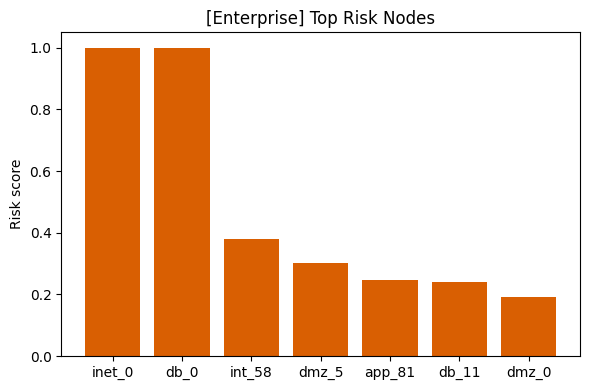


Total eligible cost: 566,360 | mid budget (5%): 28,318 | IDS nodes chosen: 15 | spend≈27,759
  [Saved] results/phase2_enterprise_risk_heatmap.png


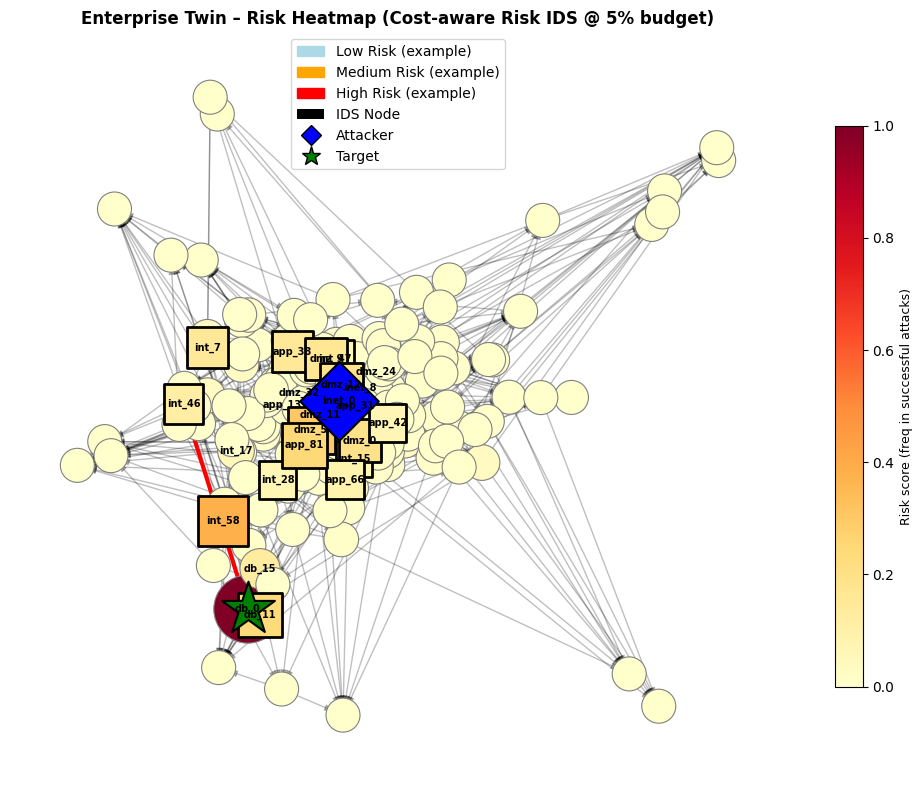

  [Saved] results/phase2_detection_vs_monetary_budget.png


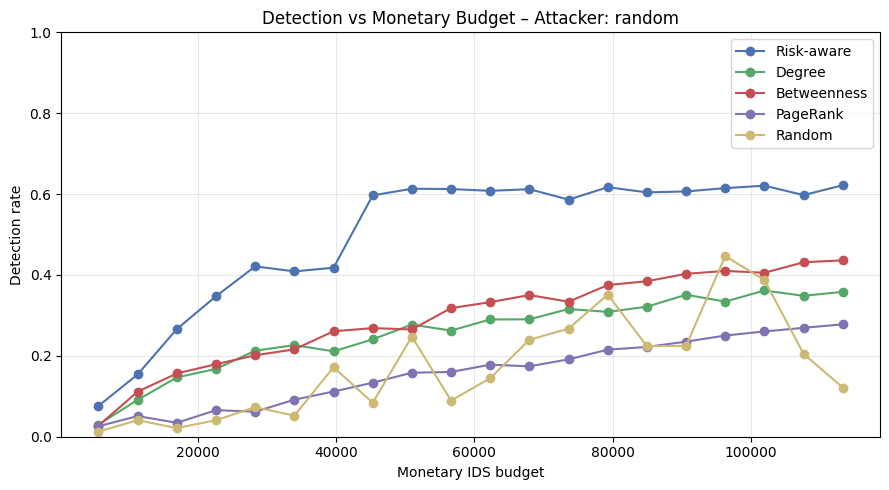


[Summary @ max budget]
  Risk-aware    budget=113,272  det=0.622
  Degree        budget=113,272  det=0.358
  Betweenness   budget=113,272  det=0.436
  PageRank      budget=113,272  det=0.278
  Random        budget=113,272  det=0.122


In [ ]:

# Phase-2: Cost-aware IDS Placement + Enterprise Twin + Budget Curves


import os, random, time, math
from collections import Counter
from typing import Dict, List, Tuple, Set, Optional

import networkx as nx
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

------------------------
os.makedirs("results", exist_ok=True)


SEED = 42
random.seed(SEED)
plt.style.use("seaborn-v0_8-deep")

FAST_DEMO = False
NUM_ATTACKS = 3000 if FAST_DEMO else 8000
MAX_STEPS   = 50


P_DETECT_ON_IDS = 0.95


ATTACKER_MODE = "random"         # "random" | "mpp" | "stealthy" | "noisy"


APPROX_BETWEENNESS = True
BETWEENNESS_K      = 200


def safe_sample(population, k: int):

    if population is None:
        return []
    try:
        items = list(population)
    except TypeError:
        return []
    n = len(items)
    if n == 0 or k <= 0:
        return []
    k = min(k, n)
    random.shuffle(items)
    return items[:k]

# -------------------------
# CVE/CVSS vulnerability modeling (with fallback proxy)
# -------------------------
CVE_CATALOG: Dict[str, List[Dict]] = {
    "reverse_proxy": [
        {"cve": "CVE-2023-25690", "cvss_base": 9.8, "exploitability": 3.9},
        {"cve": "CVE-2022-31813", "cvss_base": 7.5, "exploitability": 2.8},
    ],
    "web_app": [
        {"cve": "CVE-2023-28432", "cvss_base": 8.8, "exploitability": 3.9},
        {"cve": "CVE-2022-3602",  "cvss_base": 8.2, "exploitability": 3.9},
    ],
    "auth_service": [
        {"cve": "CVE-2023-23397", "cvss_base": 9.8, "exploitability": 3.9},
        {"cve": "CVE-2021-44228", "cvss_base": 10.0, "exploitability": 3.9},
    ],
    "dbms": [
        {"cve": "CVE-2022-21587", "cvss_base": 9.8, "exploitability": 3.9},
        {"cve": "CVE-2021-44228", "cvss_base": 10.0, "exploitability": 3.9},
    ],
    "cache": [
        {"cve": "CVE-2022-0543",  "cvss_base": 10.0, "exploitability": 3.9},
        {"cve": "CVE-2021-42306", "cvss_base": 7.5,  "exploitability": 2.8},
    ],
    "message_queue": [
        {"cve": "CVE-2022-33980", "cvss_base": 8.1, "exploitability": 3.9},
        {"cve": "CVE-2021-30116", "cvss_base": 7.5, "exploitability": 2.8},
    ],
    "file_share": [
        {"cve": "CVE-2020-0796", "cvss_base": 10.0, "exploitability": 3.9},
        {"cve": "CVE-2017-0144", "cvss_base": 8.1,  "exploitability": 3.9},
    ],
    "scada_gateway": [
        {"cve": "CVE-2022-26809", "cvss_base": 9.8, "exploitability": 3.9},
        {"cve": "CVE-2021-32934", "cvss_base": 8.8, "exploitability": 3.9},
    ],
    "smb": [
        {"cve": "CVE-2021-1675", "cvss_base": 7.5, "exploitability": 2.8},
        {"cve": "CVE-2017-0143", "cvss_base": 8.1, "exploitability": 3.9},
    ],
    "ssh": [
        {"cve": "CVE-2023-48795", "cvss_base": 7.5, "exploitability": 2.8},
        {"cve": "CVE-2020-15778", "cvss_base": 7.8, "exploitability": 3.9},
    ],
    "rdp": [
        {"cve": "CVE-2019-0708", "cvss_base": 9.8, "exploitability": 3.9},
        {"cve": "CVE-2020-0609", "cvss_base": 9.8, "exploitability": 3.9},
    ],
    "ldap": [
        {"cve": "CVE-2020-25709", "cvss_base": 7.5, "exploitability": 2.8},
        {"cve": "CVE-2020-25692", "cvss_base": 8.8, "exploitability": 3.9},
    ],
}

SERVICE_CVSS_PROXY = {
    "reverse_proxy": 7.2, "web_app": 8.8, "auth_service": 8.0, "dbms": 9.1,
    "cache": 6.0, "message_queue": 7.0, "file_share": 6.8, "scada_gateway": 8.5,
    "smb": 7.5, "ssh": 7.3, "rdp": 8.5, "ldap": 7.8,
}

EDGE_ACTION_MULT = {
    "lateral": 1.0, "priv_esc": 1.15, "cred_theft": 1.10, "pivot": 1.05
}
ROLE_EXPLOITABILITY = {
    "internet": 1.10, "dmz": 1.05, "app": 1.00,
    "internal": 0.95, "db": 0.90, "scada": 0.90
}

def _p_from_cve_entry(entry: Dict) -> float:
    base = float(entry.get("cvss_base", 0.0)) / 10.0
    expl = float(entry.get("exploitability", 0.0)) / 10.0
    return max(0.0, min(1.0, base * expl))

def _combine_noisy_or(probs: List[float]) -> float:
    if not probs:
        return 0.0
    prod = 1.0
    for p in probs:
        prod *= (1 - max(0.0, min(1.0, p)))
    return 1.0 - prod

def p_service_from_cves(service: str) -> Optional[float]:
    entries = CVE_CATALOG.get(service, [])
    if not entries:
        return None
    return float(min(0.98, max(0.02, _combine_noisy_or([_p_from_cve_entry(e) for e in entries]))))

def p_node_from_services_cves(services: List[str]) -> Optional[float]:
    ps = []
    for svc in services or []:
        p_svc = p_service_from_cves(svc)
        if p_svc is not None:
            ps.append(p_svc)
    if not ps:
        return None
    return float(min(0.98, max(0.02, _combine_noisy_or(ps))))

def _fallback_node_base_compromise_prob(services: List[str], role: str) -> float:
    if not services:
        base = 0.2
    else:
        svals = [SERVICE_CVSS_PROXY.get(s, 6.5) for s in services]
        base  = sum(svals) / (10.0 * len(svals))
    p = base * ROLE_EXPLOITABILITY.get(role, 1.0)
    return float(min(0.98, max(0.05, p)))

def edge_p_compromise(src_role: str, dst_role: str, dst_services: List[str], action: str) -> float:

    p_node = p_node_from_services_cves(dst_services)
    if p_node is None:
        p_node = _fallback_node_base_compromise_prob(dst_services, dst_role)
    role_mult   = ROLE_EXPLOITABILITY.get(dst_role, 1.0)
    action_mult = EDGE_ACTION_MULT.get(action, 1.0)
    p = p_node * role_mult * action_mult
    return float(min(0.98, max(0.05, p)))

def print_cve_summary_for_graph(G: nx.DiGraph, max_services: int = 12, sample_edges: int = 8):
    svc_present = sorted({svc for n in G.nodes() for svc in G.nodes[n].get("services", [])})
    print("\n=== CVE/CVSS Vulnerability Model Summary ===")
    print("Services present:", ", ".join(svc_present[:max_services]) +
          (" ..." if len(svc_present) > max_services else ""))
    print("\nService → example CVE and aggregated p_service:")
    for svc in svc_present[:max_services]:
        entries = CVE_CATALOG.get(svc, [])
        if not entries:
            print(f"  {svc:16s}  (no CVEs in catalog) -> using fallback proxy")
        else:
            top   = sorted(entries, key=lambda e: e.get("cvss_base", 0.0), reverse=True)[0]
            p_svc = p_service_from_cves(svc)
            print(f"  {svc:16s}  top={top['cve']}  base={top['cvss_base']:.1f}"
                  f"  expl={top['exploitability']:.1f}  p_service≈{p_svc:.3f}")
    edges = list(G.edges())
    random.shuffle(edges)
    print(f"\nSample of {min(sample_edges, len(edges))} edges with p_compromise:")
    for (u, v) in edges[:sample_edges]:
        role_v = G.nodes[v].get("role", "app")
        svcs   = G.nodes[v].get("services", [])
        action = G[u][v].get("action", "lateral")
        p      = edge_p_compromise(G.nodes[u].get("role", "app"), role_v, svcs, action)
        used   = "CVE-BASED" if p_node_from_services_cves(svcs) is not None else "FALLBACK"
        print(f"  {str(u)} -> {str(v):15}  action={action:10}  role_v={role_v:9}"
              f"  svcs={svcs}  | {used:9}  p≈{p:.3f}")


def _pick_services_for_role(role: str) -> List[str]:
    if role == "internet": return ["reverse_proxy", "ssh"]
    if role == "dmz":      return ["reverse_proxy"]
    if role == "app":      return ["web_app", "auth_service"]
    if role == "internal": return ["file_share", "ldap"]
    if role == "db":       return ["dbms"]
    if role == "scada":    return ["scada_gateway"]
    return ["web_app"]

def _connect_layer(G, src_nodes: List, dst_nodes: List, out_per_src: int, action: str):

    if not src_nodes or not dst_nodes or out_per_src <= 0:
        return
    for u in src_nodes:
        vs = safe_sample(dst_nodes, out_per_src)   # FIX: safe_sample clamps k
        for v in vs:
            p = edge_p_compromise(
                G.nodes[u]["role"], G.nodes[v]["role"],
                G.nodes[v]["services"], action
            )
            G.add_edge(u, v, action=action, p_compromise=p)

def _connect_lateral(G, nodes: List, edges_per_node: int, action: str = "lateral"):

    if not nodes or len(nodes) < 2 or edges_per_node <= 0:
        return
    for u in nodes:
        peers = [x for x in nodes if x != u]
        vs    = safe_sample(peers, edges_per_node)
        for v in vs:
            if random.random() < 0.5:
                if not G.has_edge(u, v):
                    p = edge_p_compromise(
                        G.nodes[u]["role"], G.nodes[v]["role"],
                        G.nodes[v]["services"], action
                    )
                    G.add_edge(u, v, action=action, p_compromise=p)
            else:
                if not G.has_edge(v, u):
                    p = edge_p_compromise(
                        G.nodes[v]["role"], G.nodes[u]["role"],
                        G.nodes[u]["services"], action
                    )
                    G.add_edge(v, u, action=action, p_compromise=p)

def build_enterprise_twin(
    sizes:  Dict[str, int] = None,
    wiring: Dict[str, int] = None,
    seed:   int = SEED
):

    random.seed(seed)
    if sizes is None:
        sizes = {
            "internet": 15 if FAST_DEMO else 25,
            "dmz":      20 if FAST_DEMO else 35,
            "app":      45 if FAST_DEMO else 85,
            "internal": 35 if FAST_DEMO else 60,
            "db":        8 if FAST_DEMO else 20,
            "scada":     4 if FAST_DEMO else 10,
        }
    if wiring is None:
        wiring = {
            "internet_to_dmz": 3,  "dmz_to_app": 3,
            "app_to_internal": 2,  "internal_to_db": 2, "internal_to_scada": 1,
            "lateral_internet": 1, "lateral_dmz": 1,    "lateral_app": 1,
            "lateral_internal": 1, "lateral_db": 1,     "lateral_scada": 1,
        }


    sizes = {k: max(0, int(v)) for k, v in sizes.items()}

    G        = nx.DiGraph()
    internet = [f"inet_{i}"  for i in range(sizes.get("internet", 0))]
    dmz      = [f"dmz_{i}"   for i in range(sizes.get("dmz",      0))]
    app      = [f"app_{i}"   for i in range(sizes.get("app",      0))]
    internal = [f"int_{i}"   for i in range(sizes.get("internal", 0))]
    db       = [f"db_{i}"    for i in range(sizes.get("db",       0))]
    scada    = [f"scada_{i}" for i in range(sizes.get("scada",    0))]

    for nd in internet: G.add_node(nd, role="internet", services=_pick_services_for_role("internet"))
    for nd in dmz:      G.add_node(nd, role="dmz",      services=_pick_services_for_role("dmz"))
    for nd in app:      G.add_node(nd, role="app",      services=_pick_services_for_role("app"))
    for nd in internal: G.add_node(nd, role="internal", services=_pick_services_for_role("internal"))
    for nd in db:       G.add_node(nd, role="db",       services=_pick_services_for_role("db"))
    for nd in scada:    G.add_node(nd, role="scada",    services=_pick_services_for_role("scada"))

    # Inter-layer edges
    _connect_layer(G, internet, dmz,      wiring.get("internet_to_dmz",  0), "pivot")
    _connect_layer(G, dmz,      app,      wiring.get("dmz_to_app",       0), "lateral")
    _connect_layer(G, app,      internal, wiring.get("app_to_internal",   0), "cred_theft")
    _connect_layer(G, internal, db,       wiring.get("internal_to_db",    0), "priv_esc")
    _connect_layer(G, internal, scada,    wiring.get("internal_to_scada", 0), "priv_esc")

    # Lateral edges within each layer
    _connect_lateral(G, internet, wiring.get("lateral_internet", 0))
    _connect_lateral(G, dmz,      wiring.get("lateral_dmz",      0))
    _connect_lateral(G, app,      wiring.get("lateral_app",      0))
    _connect_lateral(G, internal, wiring.get("lateral_internal",  0))
    _connect_lateral(G, db,       wiring.get("lateral_db",       0))
    _connect_lateral(G, scada,    wiring.get("lateral_scada",    0))

    # Guarantee a canonical attacker -> target reachability chain
    chain = []
    if internet: chain.append(internet[0])
    if dmz:      chain.append(dmz[0])
    if app:      chain.append(app[0])
    if internal: chain.append(internal[0])
    if db:       chain.append(db[0])
    elif scada:  chain.append(scada[0])
    for u, v in zip(chain[:-1], chain[1:]):
        if not G.has_edge(u, v):
            action = "lateral" if G.nodes[v]["role"] in {"dmz", "app", "internal"} else "priv_esc"
            p = edge_p_compromise(
                G.nodes[u]["role"], G.nodes[v]["role"],
                G.nodes[v]["services"], action
            )
            G.add_edge(u, v, action=action, p_compromise=p)

    attacker = internet[0] if internet else list(G.nodes())[0]
    target   = (db[0] if db else
                (scada[0] if scada else
                 max(G.nodes(), key=lambda nd: G.degree(nd))))

    # FIX: compute and return pos so callers can unpack 4 values
    pos = nx.spring_layout(G, seed=seed, k=1.2 / max(1, G.number_of_nodes() ** 0.5))
    return G, attacker, target, pos   # FIX: was returning only 3 values


# Attacker models

def simulate_random(G, s, t, max_steps):
    current = s; path = [current]; visited = {current}; steps = 0
    while current != t and steps < max_steps:
        succ = [v for v in G.successors(current) if v not in visited]
        if not succ: return False, path
        weights = [G[current][v].get("p_compromise", 0.5) for v in succ]
        nxt = random.choices(succ, weights=weights, k=1)[0]
        p   = G[current][nxt].get("p_compromise", 0.5)
        if random.random() <= p:
            current = nxt; path.append(current); visited.add(current); steps += 1
        else:
            return False, path
    return (current == t), path

def most_probable_path(G, s, t):
    H = G.copy()
    for u, v in H.edges():
        p = max(1e-6, H[u][v].get("p_compromise", 0.5))
        H[u][v]["w"] = -math.log(p)
    try:
        return nx.shortest_path(H, s, t, weight="w")
    except nx.NetworkXNoPath:
        return None

def simulate_mpp(G, s, t):
    pth = most_probable_path(G, s, t)
    if not pth: return False, [s]
    cur = pth[0]
    for nxt in pth[1:]:
        p = G[cur][nxt].get("p_compromise", 0.5)
        if random.random() > p:
            idx = pth.index(nxt)
            return False, pth[:idx]
        cur = nxt
    return True, pth

def simulate_degree_biased(G, s, t, max_steps, prefer_low_degree=True):
    current = s; path = [current]; visited = {current}; steps = 0
    while current != t and steps < max_steps:
        succ = [v for v in G.successors(current) if v not in visited]
        if not succ: return False, path
        degs  = [G.degree(v) + 1 for v in succ]
        probs = [G[current][v].get("p_compromise", 0.5) for v in succ]
        if prefer_low_degree:
            weights = [(1.0 / d) * p for d, p in zip(degs, probs)]   # stealthy
        else:
            weights = [d * p for d, p in zip(degs, probs)]            # noisy
        nxt = random.choices(succ, weights=weights, k=1)[0]
        p   = G[current][nxt].get("p_compromise", 0.5)
        if random.random() <= p:
            current = nxt; path.append(current); visited.add(current); steps += 1
        else:
            return False, path
    return (current == t), path

def simulate_single_attack(G, s, t, mode="random", max_steps=50):
    if mode == "random":   return simulate_random(G, s, t, max_steps)
    if mode == "mpp":      return simulate_mpp(G, s, t)
    if mode == "stealthy": return simulate_degree_biased(G, s, t, max_steps, prefer_low_degree=True)
    if mode == "noisy":    return simulate_degree_biased(G, s, t, max_steps, prefer_low_degree=False)
    return simulate_random(G, s, t, max_steps)


# Risk scoring & detection

def monte_carlo_attack_stats(
    G, s, t,
    n_sims=NUM_ATTACKS, max_steps=MAX_STEPS, attacker_mode=ATTACKER_MODE
):
    t0 = time.time()
    node_counter  = Counter()
    success_count = 0
    samples       = []
    for _ in range(n_sims):
        success, path = simulate_single_attack(G, s, t, mode=attacker_mode, max_steps=max_steps)
        if success:
            success_count += 1
            for nd in path: node_counter[nd] += 1
            if len(samples) < 10: samples.append(path)
    denom = success_count if success_count > 0 else 1
    risk  = {nd: node_counter[nd] / denom for nd in G.nodes()}
    t1    = time.time()
    return risk, success_count / n_sims, samples, (t1 - t0)

def evaluate_detection_rate(
    G, s, t, ids_nodes: Set,
    n_sims=NUM_ATTACKS // 2, max_steps=MAX_STEPS,
    attacker_mode=ATTACKER_MODE, p_detect=P_DETECT_ON_IDS
):
    t0        = time.time()
    detected  = 0

    ids_nodes = set(ids_nodes) & set(G.nodes())
    for _ in range(n_sims):
        success, path = simulate_single_attack(G, s, t, mode=attacker_mode, max_steps=max_steps)
        if any((nd in ids_nodes) and (random.random() <= p_detect) for nd in path):
            detected += 1
    t1 = time.time()
    return detected / n_sims, (t1 - t0)


def centrality_degree(G) -> Dict:
    return {nd: G.degree(nd) for nd in G.nodes()}

def centrality_betweenness(G) -> Dict:
    n = G.number_of_nodes()
    if n == 0:
        return {}
    if APPROX_BETWEENNESS:

        k_eff = min(BETWEENNESS_K, n) if BETWEENNESS_K and BETWEENNESS_K > 0 else min(100, n)
        return nx.betweenness_centrality(
            G.to_undirected(), normalized=False, k=k_eff, seed=SEED
        )
    return nx.betweenness_centrality(G.to_undirected(), normalized=False)

def centrality_pagerank(G) -> Dict:
    return nx.pagerank(G, alpha=0.85)


ROLE_MONITOR_COST = {
    "internet": 5000, "dmz": 3000, "app": 1500,
    "internal": 1200, "db": 4000,  "scada": 6000
}

def assign_monitor_costs(G, noise_frac: float = 0.2):
    for nd in G.nodes():
        role   = G.nodes[nd].get("role", "app")
        base   = ROLE_MONITOR_COST.get(role, 2000)
        jitter = 1.0 + random.uniform(-noise_frac, noise_frac)
        cost   = max(200, int(base * jitter))
        G.nodes[nd]["monitor_cost"] = cost

def cost_aware_select_by_ratio(
    scores: Dict, costs: Dict, budget: float, exclude: Set
) -> Set:

    items  = [(nd, scores.get(nd, 0.0), costs.get(nd, 1e12))
              for nd in scores if nd not in exclude]
    items  = [(nd, v, c) for nd, v, c in items if 0 < c < 1e11]
    items.sort(key=lambda x: x[1] / x[2] if x[2] > 0 else 0.0, reverse=True)
    chosen = set(); spend = 0.0
    for nd, v, c in items:
        if spend + c <= budget:
            chosen.add(nd); spend += c
    return chosen

def cost_aware_select_random(G, budget: float, costs: Dict, exclude: Set) -> Set:
    cand = [nd for nd in G.nodes() if nd not in exclude]
    random.shuffle(cand)
    chosen = set(); spend = 0.0
    for nd in cand:
        c = costs.get(nd, 1e12)
        if spend + c <= budget:
            chosen.add(nd); spend += c
    return chosen

def cost_aware_candidates(
    G, ranking_scores: Dict, exclude: Set, budget: float
) -> Dict[str, Set]:
    costs = {nd: G.nodes[nd].get("monitor_cost", 999999) for nd in G.nodes()}
    deg   = centrality_degree(G)
    btw   = centrality_betweenness(G)
    pr    = centrality_pagerank(G)
    return {
        "Risk-aware":  cost_aware_select_by_ratio(ranking_scores, costs, budget, exclude),
        "Degree":      cost_aware_select_by_ratio(deg,            costs, budget, exclude),
        "Betweenness": cost_aware_select_by_ratio(btw,            costs, budget, exclude),
        "PageRank":    cost_aware_select_by_ratio(pr,             costs, budget, exclude),
        "Random":      cost_aware_select_random(G,                budget, costs, exclude),
    }


def draw_risk_heatmap(
    G, risk, ids_nodes, source, target, title,
    pos=None, annotate=True, label_top_k=20,
    attack_path=None, save_path: Optional[str] = None   # FIX: new param
):
    fig, ax = plt.subplots(figsize=(10, 8))
    if pos is None:
        pos = nx.spring_layout(G, seed=SEED)

    max_risk = max(risk.values()) if risk else 1.0
    norm     = Normalize(vmin=0.0, vmax=max_risk if max_risk > 0 else 1.0)
    cmap     = matplotlib.colormaps.get_cmap("YlOrRd")

    values = [risk.get(nd, 0.0) for nd in G.nodes()]
    sizes  = [600 + 1800 * (v / (max_risk if max_risk > 0 else 1.0)) for v in values]
    colors = [cmap(norm(v)) for v in values]

    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.25, arrows=True,
                           arrowstyle="-|>", arrowsize=10, width=1.0)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=colors, node_size=sizes,
                           node_shape="o", edgecolors="gray", linewidths=0.8)

    if attack_path and len(attack_path) >= 2:
        path_edges = list(zip(attack_path[:-1], attack_path[1:]))
        nx.draw_networkx_edges(G, pos, ax=ax, edgelist=path_edges,
                               edge_color="red", width=3, arrows=True)

    if ids_nodes:
        size_map  = {nd: s for nd, s in zip(G.nodes(), sizes)}
        ids_sizes = [size_map.get(nd, 1000) for nd in ids_nodes]
        ids_cols  = [cmap(norm(risk.get(nd, 0.0))) for nd in ids_nodes]
        nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=list(ids_nodes),
                               node_color=ids_cols, node_size=ids_sizes,
                               node_shape="s", edgecolors="black", linewidths=2.0)

    nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=[source],
                           node_color="blue",  node_size=1600,
                           node_shape="D", edgecolors="black", linewidths=1.5)
    nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=[target],
                           node_color="green", node_size=1600,
                           node_shape="*", edgecolors="black", linewidths=1.5)

    if annotate:
        if len(G) <= label_top_k:
            nx.draw_networkx_labels(G, pos, ax=ax, font_size=8, font_weight="bold")
        else:
            top = sorted(risk.items(), key=lambda x: x[1], reverse=True)[:label_top_k]
            nx.draw_networkx_labels(G, pos,
                                    labels={nd: str(nd) for nd, _ in top},
                                    ax=ax, font_size=7, font_weight="bold")

    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, shrink=0.75)
    cbar.set_label("Risk score (freq in successful attacks)", fontsize=9)

    legend_elements = [
        mpatches.Patch(color="lightblue", label="Low Risk (example)"),
        mpatches.Patch(color="orange",    label="Medium Risk (example)"),
        mpatches.Patch(color="red",       label="High Risk (example)"),
        mpatches.Patch(facecolor="black", label="IDS Node"),
        Line2D([0], [0], marker="D", color="w", label="Attacker",
               markerfacecolor="blue",  markeredgecolor="black", markersize=10, linestyle="None"),
        Line2D([0], [0], marker="*", color="w", label="Target",
               markerfacecolor="green", markeredgecolor="black", markersize=14, linestyle="None"),
    ]
    ax.legend(handles=legend_elements, loc="best")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_axis_off()
    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
        print(f"  [Saved] {save_path}")
    plt.show()

def show_top_risk_bar(
    risk: Dict, top_k: int = 7, title: str = "Top Risk Nodes",
    save_path: Optional[str] = None   # FIX: new param
):
    top   = sorted(risk.items(), key=lambda x: x[1], reverse=True)[:top_k]
    print("\nTop Risk Nodes:")
    for nd, v in top:
        print(nd, round(v, 3))
    names = [str(nd) for nd, _ in top]
    vals  = [v for _, v in top]


    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(names, vals, color="#d95f02")
    ax.set_title(title)
    ax.set_ylabel("Risk score")
    fig.tight_layout()


    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
        print(f"  [Saved] {save_path}")
    plt.show()

def print_network_stats(G, label: str = "Network Statistics"):
    avg_deg = sum(dict(G.degree()).values()) / max(1, G.number_of_nodes())
    print(f"\n{label}")
    print(f"Nodes: {G.number_of_nodes()} | Edges: {G.number_of_edges()} | Avg degree: {avg_deg:.2f}")

# Experiment: Detection vs Monetary Budget (1%..20%)

def detection_vs_monetary_budget(
    G, s, t, attacker_mode, risk_scores, exclude: Set,
    budgets: List[float], max_steps: int, sims_per_point: int,
    save_path: Optional[str] = None   # FIX: new param
):
    results: Dict[str, List[float]] = {
        "Risk-aware": [], "Degree": [], "Betweenness": [], "PageRank": [], "Random": []
    }

    for B in budgets:
        cand_sets = cost_aware_candidates(G, risk_scores, exclude, budget=B)
        for name, ids_nodes in cand_sets.items():
            det, _ = evaluate_detection_rate(
                G, s, t, ids_nodes,
                n_sims=sims_per_point,
                max_steps=max_steps,
                attacker_mode=attacker_mode
            )
            results[name].append(det)


    fig, ax = plt.subplots(figsize=(9, 5))
    for name, y in results.items():
        ax.plot(budgets, y, marker="o", label=name)
    ax.set_ylim(0, 1.0)
    ax.set_xlabel("Monetary IDS budget")
    ax.set_ylabel("Detection rate")
    ax.set_title(f"Detection vs Monetary Budget – Attacker: {attacker_mode}")
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()


    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
        print(f"  [Saved] {save_path}")
    plt.show()


    print("\n[Summary @ max budget]")
    Bmax = budgets[-1]
    for name, ys in results.items():
        print(f"  {name:12s}  budget={Bmax:,.0f}  det={ys[-1]:.3f}")
    return results


def run_phase2(attacker_mode=ATTACKER_MODE):
    print("\n=== Phase-2: Cost-aware IDS + Enterprise Twin ===")
    print(f"Random seed: {SEED} | FAST_DEMO={FAST_DEMO} | Attacker mode={attacker_mode}")

    # 1) Build enterprise twin
    # FIX: unpack 4 values — pos is now returned by build_enterprise_twin
    G, s, t, pos = build_enterprise_twin()
    assign_monitor_costs(G)
    print_network_stats(G, "[Enterprise] Network Stats")
    print(f"Attacker: {s} | Target: {t}")
    print_cve_summary_for_graph(G, max_services=12, sample_edges=8)

    # 2) Monte Carlo risk scoring
    print("\n[Enterprise] Monte Carlo for risk scoring...")
    risk, succ_rate, samples, mc_time = monte_carlo_attack_stats(
        G, s, t, n_sims=NUM_ATTACKS, max_steps=MAX_STEPS, attacker_mode=attacker_mode
    )
    print(f"  Success rate: {succ_rate:.3f} | time: {mc_time:.2f}s")

    # FIX: save_path passed
    show_top_risk_bar(
        risk, 7, "[Enterprise] Top Risk Nodes",
        save_path="results/phase2_enterprise_top_risk_bar.png"
    )

    # 3) Heatmap @ 5% of total eligible cost
    eligible   = [nd for nd in G.nodes() if nd not in {s, t}]
    total_cost = sum(G.nodes[nd]["monitor_cost"] for nd in eligible) if eligible else 0.0
    mid_budget = 0.05 * total_cost
    cand_sets  = cost_aware_candidates(G, risk, exclude={s, t}, budget=mid_budget)
    ids_risk_cost = cand_sets["Risk-aware"]
    spend_mid  = sum(G.nodes[nd]["monitor_cost"] for nd in ids_risk_cost)
    print(f"\nTotal eligible cost: {total_cost:,.0f} | mid budget (5%): {mid_budget:,.0f}"
          f" | IDS nodes chosen: {len(ids_risk_cost)} | spend≈{spend_mid:,.0f}")

    # FIX: save_path passed; use pos returned by build_enterprise_twin
    draw_risk_heatmap(
        G, risk, ids_risk_cost, s, t,
        title="Enterprise Twin – Risk Heatmap (Cost-aware Risk IDS @ 5% budget)",
        pos=pos,
        annotate=True, label_top_k=25,
        attack_path=(samples[0] if samples else None),
        save_path="results/phase2_enterprise_risk_heatmap.png"   # FIX: saved
    )

    # 4) Detection vs Monetary Budget curves (1%..20%)
    steps          = list(range(1, 21, 1))   # 1% .. 20%
    budgets        = [total_cost * (p / 100.0) for p in steps]
    sims_per_point = min(3000, max(1200, NUM_ATTACKS // 3))

    _ = detection_vs_monetary_budget(
        G, s, t, attacker_mode,
        risk_scores=risk,
        exclude={s, t},
        budgets=budgets,
        max_steps=MAX_STEPS,
        sims_per_point=sims_per_point,
        save_path="results/phase2_detection_vs_monetary_budget.png"  # FIX: saved
    )

# Entry point

run_phase2(attacker_mode="random")   # swap to "mpp", "stealthy", or "noisy"


=== Phase-3: Dynamic + Scalability (CVE-consistent & Robust) ===

=== Dynamic Reconfiguration Experiment ===

[Baseline] Enterprise Twin
Nodes: 235 | Edges: 769 | Avg degree: 6.54

=== CVE/CVSS Vulnerability Model Summary ===
Services present: auth_service, dbms, file_share, ldap, reverse_proxy, scada_gateway, ssh, web_app

Service → example CVE and aggregated p_service:
  auth_service      top=CVE-2021-44228  base=10.0  expl=3.9  p_service≈0.623
  dbms              top=CVE-2021-44228  base=10.0  expl=3.9  p_service≈0.623
  file_share        top=CVE-2020-0796  base=10.0  expl=3.9  p_service≈0.583
  ldap              top=CVE-2020-25692  base=8.8  expl=3.9  p_service≈0.481
  reverse_proxy     top=CVE-2023-25690  base=9.8  expl=3.9  p_service≈0.512
  scada_gateway     top=CVE-2022-26809  base=9.8  expl=3.9  p_service≈0.594
  ssh               top=CVE-2020-15778  base=7.8  expl=3.9  p_service≈0.450
  web_app           top=CVE-2023-28432  base=8.8  expl=3.9  p_service≈0.553

Sample of 6 ed

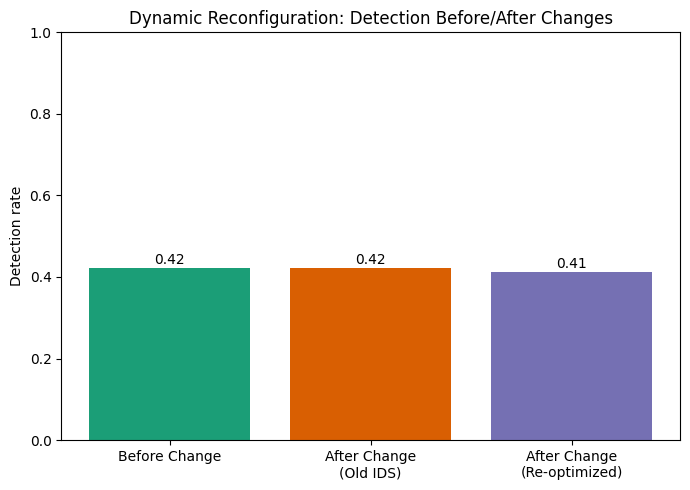

  [Saved] results/phase3_dynamic_updated_heatmap.png


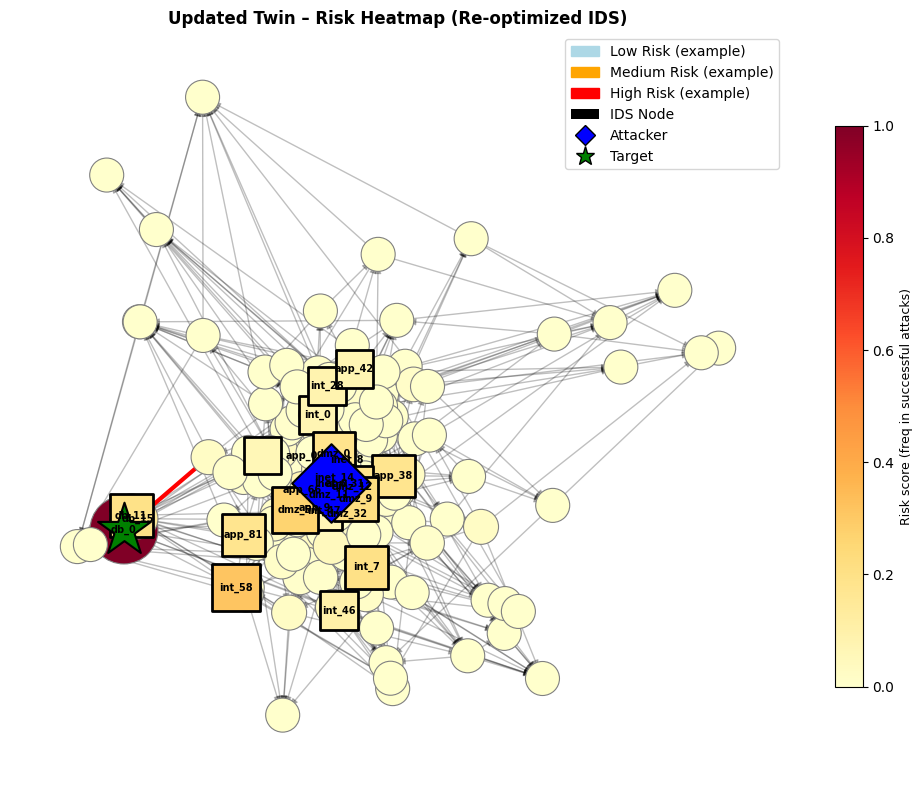


Top Risk Nodes:
inet_0 1.0
db_0 1.0
int_58 0.314
dmz_5 0.268
dmz_9 0.216
inet_8 0.203
int_7 0.203
  [Saved] results/phase3_dynamic_top_risk_bar.png


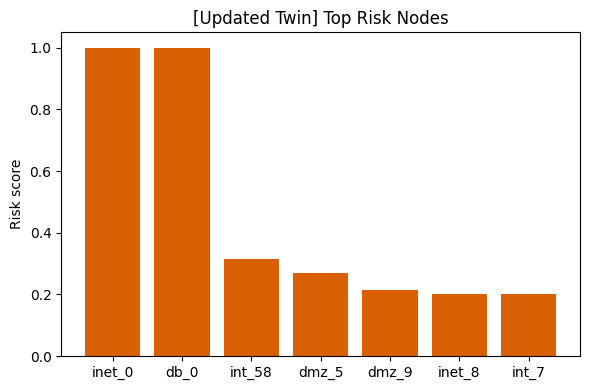


=== Scalability Benchmark ===
N=  100 | sims=1050 | success_rate=0.031 | det=0.238 | time=0.05s
N=  500 | sims=1250 | success_rate=0.005 | det=0.406 | time=0.54s
N= 1000 | sims=1500 | success_rate=0.004 | det=0.549 | time=0.71s
N= 5000 | sims=3500 | success_rate=0.001 | det=0.122 | time=4.91s
N=10000 | sims=4000 | success_rate=0.001 | det=0.092 | time=12.62s
  [Saved] results/phase3_scalability_runtime.png


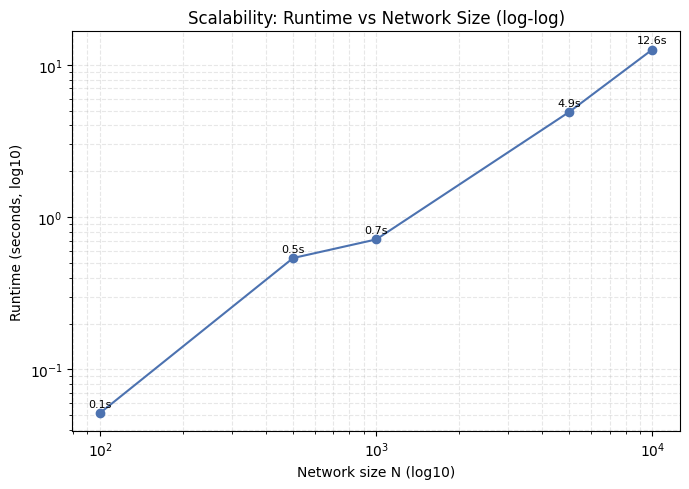

In [ ]:

# Phase-3 (CVE-Consistent & Robust): Dynamic Reconfiguration + Scalability

import os, random, time, math
from collections import Counter
from typing import Dict, List, Tuple, Set, Optional

import networkx as nx
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# Ensure results/ folder exists

os.makedirs("results", exist_ok=True)


# Global config

SEED = 42
random.seed(SEED)
plt.style.use("seaborn-v0_8-deep")

FAST_DEMO         = False
NUM_ATTACKS_LARGE = 3000 if FAST_DEMO else 8000
MAX_STEPS_LARGE   = 50

# Imperfect detection
P_DETECT_ON_IDS = 0.95

# Default attacker mode
ATTACKER_MODE = "random"    # "random" | "mpp" | "stealthy" | "noisy"

# Approximate betweenness config
APPROX_BETWEENNESS = True
BETWEENNESS_K      = 200


# Safe sampling helper

def safe_sample(population, k: int):

    if population is None:
        return []
    try:
        items = list(population)
    except TypeError:
        return []
    n = len(items)
    if n == 0 or k <= 0:
        return []
    k = min(k, n)
    random.shuffle(items)
    return items[:k]

def safe_first(seq, default=None):
    return next(iter(seq), default)


# CVE/CVSS vulnerability modeling

CVE_CATALOG: Dict[str, List[Dict]] = {
    "reverse_proxy": [
        {"cve": "CVE-2023-25690", "cvss_base": 9.8, "exploitability": 3.9},
        {"cve": "CVE-2022-31813", "cvss_base": 7.5, "exploitability": 2.8},
    ],
    "web_app": [
        {"cve": "CVE-2023-28432", "cvss_base": 8.8, "exploitability": 3.9},
        {"cve": "CVE-2022-3602",  "cvss_base": 8.2, "exploitability": 3.9},
    ],
    "auth_service": [
        {"cve": "CVE-2023-23397", "cvss_base": 9.8,  "exploitability": 3.9},
        {"cve": "CVE-2021-44228", "cvss_base": 10.0, "exploitability": 3.9},
    ],
    "dbms": [
        {"cve": "CVE-2022-21587", "cvss_base": 9.8,  "exploitability": 3.9},
        {"cve": "CVE-2021-44228", "cvss_base": 10.0, "exploitability": 3.9},
    ],
    "cache": [
        {"cve": "CVE-2022-0543",  "cvss_base": 10.0, "exploitability": 3.9},
        {"cve": "CVE-2021-42306", "cvss_base": 7.5,  "exploitability": 2.8},
    ],
    "message_queue": [
        {"cve": "CVE-2022-33980", "cvss_base": 8.1, "exploitability": 3.9},
        {"cve": "CVE-2021-30116", "cvss_base": 7.5, "exploitability": 2.8},
    ],
    "file_share": [
        {"cve": "CVE-2020-0796", "cvss_base": 10.0, "exploitability": 3.9},
        {"cve": "CVE-2017-0144", "cvss_base": 8.1,  "exploitability": 3.9},
    ],
    "scada_gateway": [
        {"cve": "CVE-2022-26809", "cvss_base": 9.8, "exploitability": 3.9},
        {"cve": "CVE-2021-32934", "cvss_base": 8.8, "exploitability": 3.9},
    ],
    "smb": [
        {"cve": "CVE-2021-1675", "cvss_base": 7.5, "exploitability": 2.8},
        {"cve": "CVE-2017-0143", "cvss_base": 8.1, "exploitability": 3.9},
    ],
    "ssh": [
        {"cve": "CVE-2023-48795", "cvss_base": 7.5, "exploitability": 2.8},
        {"cve": "CVE-2020-15778", "cvss_base": 7.8, "exploitability": 3.9},
    ],
    "rdp": [
        {"cve": "CVE-2019-0708", "cvss_base": 9.8, "exploitability": 3.9},
        {"cve": "CVE-2020-0609", "cvss_base": 9.8, "exploitability": 3.9},
    ],
    "ldap": [
        {"cve": "CVE-2020-25709", "cvss_base": 7.5, "exploitability": 2.8},
        {"cve": "CVE-2020-25692", "cvss_base": 8.8, "exploitability": 3.9},
    ],
}

SERVICE_CVSS_PROXY = {
    "reverse_proxy": 7.2, "web_app": 8.8, "auth_service": 8.0, "dbms": 9.1,
    "cache": 6.0, "message_queue": 7.0, "file_share": 6.8, "scada_gateway": 8.5,
    "smb": 7.5, "ssh": 7.3, "rdp": 8.5, "ldap": 7.8,
}

EDGE_ACTION_MULT = {
    "lateral": 1.0, "priv_esc": 1.15, "cred_theft": 1.10, "pivot": 1.05
}
ROLE_EXPLOITABILITY = {
    "internet": 1.10, "dmz": 1.05, "app": 1.00,
    "internal": 0.95, "db": 0.90,  "scada": 0.90
}

def _p_from_cve_entry(entry: Dict) -> float:
    base = float(entry.get("cvss_base", 0.0)) / 10.0
    expl = float(entry.get("exploitability", 0.0)) / 10.0
    return max(0.0, min(1.0, base * expl))

def _combine_noisy_or(probs: List[float]) -> float:
    if not probs:
        return 0.0
    prod = 1.0
    for p in probs:
        prod *= (1 - max(0.0, min(1.0, p)))
    return 1.0 - prod

def p_service_from_cves(service: str) -> Optional[float]:
    entries = CVE_CATALOG.get(service, [])
    if not entries:
        return None
    return float(min(0.98, max(0.02, _combine_noisy_or([_p_from_cve_entry(e) for e in entries]))))

def p_node_from_services_cves(services: List[str]) -> Optional[float]:
    ps = []
    for svc in services or []:
        p_svc = p_service_from_cves(svc)
        if p_svc is not None:
            ps.append(p_svc)
    if not ps:
        return None
    return float(min(0.98, max(0.02, _combine_noisy_or(ps))))

def _fallback_node_base_compromise_prob(services: List[str], role: str) -> float:
    if not services:
        base = 0.2
    else:
        svals = [SERVICE_CVSS_PROXY.get(s, 6.5) for s in services]
        base  = sum(svals) / (10.0 * len(svals))
    p = base * ROLE_EXPLOITABILITY.get(role, 1.0)
    return float(min(0.98, max(0.05, p)))

def edge_p_compromise(
    src_role: str, dst_role: str, dst_services: List[str], action: str
) -> float:
    p_node = p_node_from_services_cves(dst_services)
    if p_node is None:
        p_node = _fallback_node_base_compromise_prob(dst_services, dst_role)
    role_mult   = ROLE_EXPLOITABILITY.get(dst_role, 1.0)
    action_mult = EDGE_ACTION_MULT.get(action, 1.0)
    p = p_node * role_mult * action_mult
    return float(min(0.98, max(0.05, p)))

def print_cve_summary_for_graph(G: nx.DiGraph, max_services: int = 12, sample_edges: int = 8):
    svc_present = sorted({svc for n in G.nodes() for svc in G.nodes[n].get("services", [])})
    print("\n=== CVE/CVSS Vulnerability Model Summary ===")
    print("Services present:", ", ".join(svc_present[:max_services]) +
          (" ..." if len(svc_present) > max_services else ""))
    print("\nService → example CVE and aggregated p_service:")
    for svc in svc_present[:max_services]:
        entries = CVE_CATALOG.get(svc, [])
        if not entries:
            print(f"  {svc:16s}  (no CVEs in catalog) -> using fallback proxy")
        else:
            top   = sorted(entries, key=lambda e: e.get("cvss_base", 0.0), reverse=True)[0]
            p_svc = p_service_from_cves(svc)
            print(f"  {svc:16s}  top={top['cve']}  base={top['cvss_base']:.1f}"
                  f"  expl={top['exploitability']:.1f}  p_service≈{p_svc:.3f}")
    edges = list(G.edges())
    random.shuffle(edges)
    print(f"\nSample of {min(sample_edges, len(edges))} edges with p_compromise:")
    for (u, v) in edges[:sample_edges]:
        role_v = G.nodes[v].get("role", "app")
        svcs   = G.nodes[v].get("services", [])
        action = G[u][v].get("action", "lateral")
        p      = edge_p_compromise(G.nodes[u].get("role", "app"), role_v, svcs, action)
        used   = "CVE-BASED" if p_node_from_services_cves(svcs) is not None else "FALLBACK"
        print(f"  {str(u)} -> {str(v):15}  action={action:10}  role_v={role_v:9}"
              f"  svcs={svcs}  | {used:9}  p≈{p:.3f}")


# Enterprise twin generator (robust sampling, safe fallback)

def _pick_services_for_role(role: str) -> List[str]:
    if role == "internet": return ["reverse_proxy", "ssh"]
    if role == "dmz":      return ["reverse_proxy"]
    if role == "app":      return ["web_app", "auth_service"]
    if role == "internal": return ["file_share", "ldap"]
    if role == "db":       return ["dbms"]
    if role == "scada":    return ["scada_gateway"]
    return ["web_app"]

def _connect_layer(G, src_nodes: List, dst_nodes: List, out_per_src: int, action: str):
    if not src_nodes or not dst_nodes or out_per_src <= 0:
        return
    for u in src_nodes:
        vs = safe_sample(dst_nodes, out_per_src)
        for v in vs:
            p = edge_p_compromise(
                G.nodes[u]["role"], G.nodes[v]["role"],
                G.nodes[v]["services"], action
            )
            G.add_edge(u, v, action=action, p_compromise=p)

def _connect_lateral(G, nodes: List, edges_per_node: int, action: str = "lateral"):
    if not nodes or len(nodes) < 2 or edges_per_node <= 0:
        return
    for u in nodes:
        peers = [x for x in nodes if x != u]
        vs    = safe_sample(peers, edges_per_node)
        for v in vs:
            if random.random() < 0.5:
                if not G.has_edge(u, v):
                    p = edge_p_compromise(
                        G.nodes[u]["role"], G.nodes[v]["role"],
                        G.nodes[v]["services"], action
                    )
                    G.add_edge(u, v, action=action, p_compromise=p)
            else:
                if not G.has_edge(v, u):
                    p = edge_p_compromise(
                        G.nodes[v]["role"], G.nodes[u]["role"],
                        G.nodes[u]["services"], action
                    )
                    G.add_edge(v, u, action=action, p_compromise=p)

def build_enterprise_twin(
    sizes:  Dict[str, int] = None,
    wiring: Dict[str, int] = None,
    seed:   int = SEED
):
    random.seed(seed)
    if sizes is None:
        sizes = {
            "internet": 15 if FAST_DEMO else 25,
            "dmz":      20 if FAST_DEMO else 35,
            "app":      45 if FAST_DEMO else 85,
            "internal": 35 if FAST_DEMO else 60,
            "db":        8 if FAST_DEMO else 20,
            "scada":     4 if FAST_DEMO else 10,
        }
    if wiring is None:
        wiring = {
            "internet_to_dmz": 3,  "dmz_to_app": 3,
            "app_to_internal": 2,  "internal_to_db": 2, "internal_to_scada": 1,
            "lateral_internet": 1, "lateral_dmz": 1,    "lateral_app": 1,
            "lateral_internal": 1, "lateral_db": 1,     "lateral_scada": 1,
        }

    sizes = {k: max(0, int(v)) for k, v in sizes.items()}

    G        = nx.DiGraph()
    internet = [f"inet_{i}"  for i in range(sizes.get("internet", 0))]
    dmz      = [f"dmz_{i}"   for i in range(sizes.get("dmz",      0))]
    app      = [f"app_{i}"   for i in range(sizes.get("app",      0))]
    internal = [f"int_{i}"   for i in range(sizes.get("internal", 0))]
    db       = [f"db_{i}"    for i in range(sizes.get("db",       0))]
    scada    = [f"scada_{i}" for i in range(sizes.get("scada",    0))]

    for nd in internet: G.add_node(nd, role="internet", services=_pick_services_for_role("internet"))
    for nd in dmz:      G.add_node(nd, role="dmz",      services=_pick_services_for_role("dmz"))
    for nd in app:      G.add_node(nd, role="app",      services=_pick_services_for_role("app"))
    for nd in internal: G.add_node(nd, role="internal", services=_pick_services_for_role("internal"))
    for nd in db:       G.add_node(nd, role="db",       services=_pick_services_for_role("db"))
    for nd in scada:    G.add_node(nd, role="scada",    services=_pick_services_for_role("scada"))

    _connect_layer(G, internet, dmz,      wiring.get("internet_to_dmz",  0), "pivot")
    _connect_layer(G, dmz,      app,      wiring.get("dmz_to_app",       0), "lateral")
    _connect_layer(G, app,      internal, wiring.get("app_to_internal",   0), "cred_theft")
    _connect_layer(G, internal, db,       wiring.get("internal_to_db",    0), "priv_esc")
    _connect_layer(G, internal, scada,    wiring.get("internal_to_scada", 0), "priv_esc")

    _connect_lateral(G, internet, wiring.get("lateral_internet", 0))
    _connect_lateral(G, dmz,      wiring.get("lateral_dmz",      0))
    _connect_lateral(G, app,      wiring.get("lateral_app",      0))
    _connect_lateral(G, internal, wiring.get("lateral_internal",  0))
    _connect_lateral(G, db,       wiring.get("lateral_db",       0))
    _connect_lateral(G, scada,    wiring.get("lateral_scada",    0))

    # Guarantee canonical attacker -> target reachability chain
    chain = []
    if internet: chain.append(internet[0])
    if dmz:      chain.append(dmz[0])
    if app:      chain.append(app[0])
    if internal: chain.append(internal[0])
    if db:       chain.append(db[0])
    elif scada:  chain.append(scada[0])
    for u, v in zip(chain[:-1], chain[1:]):
        if not G.has_edge(u, v):
            action = "lateral" if G.nodes[v]["role"] in {"dmz","app","internal"} else "priv_esc"
            p = edge_p_compromise(
                G.nodes[u]["role"], G.nodes[v]["role"],
                G.nodes[v]["services"], action
            )
            G.add_edge(u, v, action=action, p_compromise=p)

    # Fallback: if graph is empty, build a minimal 5-node chain
    if G.number_of_nodes() == 0:
        for nd, role in [("inet_0","internet"),("dmz_0","dmz"),("app_0","app"),
                         ("int_0","internal"),("db_0","db")]:
            G.add_node(nd, role=role, services=_pick_services_for_role(role))
        G.add_edge("inet_0","dmz_0", action="pivot",
                   p_compromise=edge_p_compromise("internet","dmz",_pick_services_for_role("dmz"),"pivot"))
        G.add_edge("dmz_0","app_0",  action="lateral",
                   p_compromise=edge_p_compromise("dmz","app",_pick_services_for_role("app"),"lateral"))
        G.add_edge("app_0","int_0",  action="cred_theft",
                   p_compromise=edge_p_compromise("app","internal",_pick_services_for_role("internal"),"cred_theft"))
        G.add_edge("int_0","db_0",   action="priv_esc",
                   p_compromise=edge_p_compromise("internal","db",_pick_services_for_role("db"),"priv_esc"))
        internet, dmz, app, internal, db = ["inet_0"],["dmz_0"],["app_0"],["int_0"],["db_0"]

    attacker = internet[0] if internet else safe_first(G.nodes(), default=None)
    if attacker is None:
        raise RuntimeError("Enterprise twin has no nodes; cannot proceed.")
    target = (db[0] if db else
              (scada[0] if scada else
               max(G.nodes(), key=lambda nd: G.degree(nd))))

    pos = nx.spring_layout(G, seed=seed, k=1.2 / max(1, G.number_of_nodes() ** 0.5))
    return G, attacker, target, pos

# Attacker models

def simulate_random(G, s, t, max_steps):
    current = s; path = [current]; visited = {current}; steps = 0
    while current != t and steps < max_steps:
        succ = [v for v in G.successors(current) if v not in visited]
        if not succ: return False, path
        weights = [G[current][v].get("p_compromise", 0.5) for v in succ]
        nxt = random.choices(succ, weights=weights, k=1)[0]
        p   = G[current][nxt].get("p_compromise", 0.5)
        if random.random() <= p:
            current = nxt; path.append(current); visited.add(current); steps += 1
        else:
            return False, path
    return (current == t), path

def most_probable_path(G, s, t):
    H = G.copy()
    for u, v in H.edges():
        p = max(1e-6, H[u][v].get("p_compromise", 0.5))
        H[u][v]["w"] = -math.log(p)
    try:
        return nx.shortest_path(H, s, t, weight="w")
    except nx.NetworkXNoPath:
        return None

def simulate_mpp(G, s, t):
    pth = most_probable_path(G, s, t)
    if not pth: return False, [s]
    cur = pth[0]
    for nxt in pth[1:]:
        p = G[cur][nxt].get("p_compromise", 0.5)
        if random.random() > p:
            idx = pth.index(nxt)
            return False, pth[:idx]
        cur = nxt
    return True, pth

def simulate_degree_biased(G, s, t, max_steps, prefer_low_degree=True):
    current = s; path = [current]; visited = {current}; steps = 0
    while current != t and steps < max_steps:
        succ = [v for v in G.successors(current) if v not in visited]
        if not succ: return False, path
        degs  = [G.degree(v) + 1 for v in succ]
        probs = [G[current][v].get("p_compromise", 0.5) for v in succ]
        if prefer_low_degree:
            weights = [(1.0 / d) * p for d, p in zip(degs, probs)]
        else:
            weights = [d * p for d, p in zip(degs, probs)]
        nxt = random.choices(succ, weights=weights, k=1)[0]
        p   = G[current][nxt].get("p_compromise", 0.5)
        if random.random() <= p:
            current = nxt; path.append(current); visited.add(current); steps += 1
        else:
            return False, path
    return (current == t), path

def simulate_single_attack(G, s, t, mode="random", max_steps=50):
    if mode == "random":   return simulate_random(G, s, t, max_steps)
    if mode == "mpp":      return simulate_mpp(G, s, t)
    if mode == "stealthy": return simulate_degree_biased(G, s, t, max_steps, prefer_low_degree=True)
    if mode == "noisy":    return simulate_degree_biased(G, s, t, max_steps, prefer_low_degree=False)
    return simulate_random(G, s, t, max_steps)


# Risk scoring & evaluation

def k_shortest_paths(G, s, t, k=10, cutoff=None):
    paths = []
    try:
        gen = nx.shortest_simple_paths(G, s, t)
        for p in gen:
            if cutoff is not None and len(p) > cutoff:
                continue
            paths.append(p)
            if len(paths) >= k:
                break
    except nx.NetworkXNoPath:
        pass
    return paths

def monte_carlo_attack_stats(G, s, t, n_sims=10000, max_steps=50, attacker_mode="random"):
    t0            = time.time()
    node_counter  = Counter()
    success_count = 0
    samples       = []
    for _ in range(n_sims):
        success, path = simulate_single_attack(G, s, t, mode=attacker_mode, max_steps=max_steps)
        if success:
            success_count += 1
            for nd in path: node_counter[nd] += 1
            if len(samples) < 10: samples.append(path)
    denom = success_count if success_count > 0 else 1
    risk  = {nd: node_counter[nd] / denom for nd in G.nodes()}
    t1    = time.time()
    return risk, success_count / n_sims, samples, (t1 - t0)

def evaluate_detection_rate(
    G, s, t, ids_nodes: Set,
    n_sims=5000, max_steps=50,
    attacker_mode="random", p_detect=P_DETECT_ON_IDS
):
    t0        = time.time()
    detected  = 0
    ids_nodes = set(ids_nodes) & set(G.nodes())   # safe after node removals
    for _ in range(n_sims):
        success, path = simulate_single_attack(G, s, t, mode=attacker_mode, max_steps=max_steps)
        if any((nd in ids_nodes) and (random.random() <= p_detect) for nd in path):
            detected += 1
    t1 = time.time()
    return detected / n_sims, (t1 - t0)


# Centralities

def centrality_degree(G) -> Dict:
    return {nd: G.degree(nd) for nd in G.nodes()}

def centrality_betweenness(G) -> Dict:

    n = G.number_of_nodes()
    if n == 0:
        return {}
    if APPROX_BETWEENNESS:
        k_eff = min(BETWEENNESS_K, n) if (BETWEENNESS_K and BETWEENNESS_K > 0) else min(100, n)
        return nx.betweenness_centrality(
            G.to_undirected(), normalized=False, k=k_eff, seed=SEED
        )
    return nx.betweenness_centrality(G.to_undirected(), normalized=False)

def centrality_pagerank(G) -> Dict:
    return nx.pagerank(G, alpha=0.85)


# Cost model & cost-aware placement

ROLE_MONITOR_COST = {
    "internet": 5000, "dmz": 3000, "app": 1500,
    "internal": 1200, "db": 4000,  "scada": 6000
}

def assign_monitor_costs(G, noise_frac: float = 0.2):
    for nd in G.nodes():
        role   = G.nodes[nd].get("role", "app")
        base   = ROLE_MONITOR_COST.get(role, 2000)
        jitter = 1.0 + random.uniform(-noise_frac, noise_frac)
        cost   = max(200, int(base * jitter))
        G.nodes[nd]["monitor_cost"] = cost

def cost_aware_select_by_ratio(scores: Dict, costs: Dict, budget: float, exclude: Set) -> Set:
    items = [(nd, scores.get(nd, 0.0), costs.get(nd, 1e9))
             for nd in scores if nd not in exclude]
    items = [(nd, v, c) for nd, v, c in items if 0 < c < 1e8]
    items.sort(key=lambda x: x[1] / x[2] if x[2] > 0 else 0.0, reverse=True)
    chosen = set(); spend = 0.0
    for nd, v, c in items:
        if spend + c <= budget:
            chosen.add(nd); spend += c
    return chosen

def cost_aware_select_random(G, budget: float, costs: Dict, exclude: Set) -> Set:
    cand = [nd for nd in G.nodes() if nd not in exclude]
    random.shuffle(cand)
    chosen = set(); spend = 0.0
    for nd in cand:
        c = costs.get(nd, 1e9)
        if spend + c <= budget:
            chosen.add(nd); spend += c
    return chosen

def cost_aware_candidates(G, ranking_scores: Dict, exclude: Set, budget: float) -> Dict[str, Set]:
    costs = {nd: G.nodes[nd].get("monitor_cost", 999999) for nd in G.nodes()}
    deg   = centrality_degree(G)
    btw   = centrality_betweenness(G)
    pr    = centrality_pagerank(G)
    return {
        "Risk-aware":  cost_aware_select_by_ratio(ranking_scores, costs, budget, exclude),
        "Degree":      cost_aware_select_by_ratio(deg,            costs, budget, exclude),
        "Betweenness": cost_aware_select_by_ratio(btw,            costs, budget, exclude),
        "PageRank":    cost_aware_select_by_ratio(pr,             costs, budget, exclude),
        "Random":      cost_aware_select_random(G,                budget, costs, exclude),
    }


# Visualization helpers

def draw_risk_heatmap(
    G, risk, ids_nodes, source, target, title,
    pos=None, annotate=True, label_top_k=20,
    attack_path=None, save_path: Optional[str] = None   # FIX: new param
):
    fig, ax = plt.subplots(figsize=(10, 8))
    if pos is None:
        pos = nx.spring_layout(G, seed=SEED)

    max_risk = max(risk.values()) if risk else 1.0
    norm     = Normalize(vmin=0.0, vmax=max_risk if max_risk > 0 else 1.0)
    cmap     = matplotlib.colormaps.get_cmap("YlOrRd")

    values = [risk.get(nd, 0.0) for nd in G.nodes()]
    sizes  = [600 + 1800 * (v / (max_risk if max_risk > 0 else 1.0)) for v in values]
    colors = [cmap(norm(v)) for v in values]

    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.25, arrows=True,
                           arrowstyle="-|>", arrowsize=10, width=1.0)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=colors, node_size=sizes,
                           node_shape="o", edgecolors="gray", linewidths=0.8)

    if attack_path and len(attack_path) >= 2:
        path_edges = list(zip(attack_path[:-1], attack_path[1:]))
        nx.draw_networkx_edges(G, pos, ax=ax, edgelist=path_edges,
                               edge_color="red", width=3, arrows=True)

    if ids_nodes:
        size_map  = {nd: s for nd, s in zip(G.nodes(), sizes)}
        ids_sizes = [size_map.get(nd, 1000) for nd in ids_nodes]
        ids_cols  = [cmap(norm(risk.get(nd, 0.0))) for nd in ids_nodes]
        nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=list(ids_nodes),
                               node_color=ids_cols, node_size=ids_sizes,
                               node_shape="s", edgecolors="black", linewidths=2.0)

    nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=[source],
                           node_color="blue",  node_size=1600,
                           node_shape="D", edgecolors="black", linewidths=1.5)
    nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=[target],
                           node_color="green", node_size=1600,
                           node_shape="*", edgecolors="black", linewidths=1.5)

    if annotate:
        if len(G) <= label_top_k:
            nx.draw_networkx_labels(G, pos, ax=ax, font_size=8, font_weight="bold")
        else:
            top = sorted(risk.items(), key=lambda x: x[1], reverse=True)[:label_top_k]
            nx.draw_networkx_labels(G, pos,
                                    labels={nd: str(nd) for nd, _ in top},
                                    ax=ax, font_size=7, font_weight="bold")

    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, shrink=0.75)
    cbar.set_label("Risk score (freq in successful attacks)", fontsize=9)

    legend_elements = [
        mpatches.Patch(color="lightblue", label="Low Risk (example)"),
        mpatches.Patch(color="orange",    label="Medium Risk (example)"),
        mpatches.Patch(color="red",       label="High Risk (example)"),
        mpatches.Patch(facecolor="black", label="IDS Node"),
        Line2D([0],[0], marker="D", color="w", label="Attacker",
               markerfacecolor="blue",  markeredgecolor="black", markersize=10, linestyle="None"),
        Line2D([0],[0], marker="*", color="w", label="Target",
               markerfacecolor="green", markeredgecolor="black", markersize=14, linestyle="None"),
    ]
    ax.legend(handles=legend_elements, loc="best")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_axis_off()
    fig.tight_layout()

    # FIX: save before show
    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
        print(f"  [Saved] {save_path}")
    plt.show()

def show_top_risk_bar(
    risk: Dict, top_k: int = 5, title: str = "Top Risk Nodes",
    save_path: Optional[str] = None   # FIX: new param
):
    top   = sorted(risk.items(), key=lambda x: x[1], reverse=True)[:top_k]
    print("\nTop Risk Nodes:")
    for nd, v in top:
        print(nd, round(v, 3))
    names = [str(nd) for nd, _ in top]
    vals  = [v for _, v in top]

    # FIX: fig, ax style so fig.savefig works correctly
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(names, vals, color="#d95f02")
    ax.set_title(title)
    ax.set_ylabel("Risk score")
    fig.tight_layout()

    # FIX: save before show
    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
        print(f"  [Saved] {save_path}")
    plt.show()

def print_network_stats(G, label: str = "Network Statistics"):
    avg_deg = sum(dict(G.degree()).values()) / max(1, G.number_of_nodes())
    print(f"\n{label}")
    print(f"Nodes: {G.number_of_nodes()} | Edges: {G.number_of_edges()} | Avg degree: {avg_deg:.2f}")

# Dynamic Reconfiguration helpers

def inject_zero_day(
    G: nx.DiGraph, n_edges: int = 3, p: float = 0.99, exclude: Set = None
) -> List[Tuple]:
    exclude = exclude or set()
    edges   = [(u, v) for u, v in G.edges() if u not in exclude and v not in exclude]
    picks   = safe_sample(edges, n_edges)
    changed = []
    for u, v in picks:
        old = G[u][v].get("p_compromise", 0.5)
        G[u][v]["p_compromise"] = p
        changed.append((u, v, old))
    return changed

def remove_high_degree_nodes(
    G: nx.DiGraph, k: int = 2, exclude: Set = None
) -> List:
    exclude    = exclude or set()
    candidates = [nd for nd in G.nodes() if nd not in exclude]
    if not candidates or k <= 0:
        return []
    deg_sorted = sorted(candidates, key=lambda nd: G.degree(nd), reverse=True)
    to_remove  = deg_sorted[:min(k, len(deg_sorted))]
    if to_remove:
        G.remove_nodes_from(to_remove)
    return to_remove


# Dynamic Reconfiguration Experiment

def dynamic_reconfiguration_experiment(
    attacker_mode: str = "random",
    zero_day_edges: int = 3,
    failure_nodes: int = 2
):
    print("\n=== Dynamic Reconfiguration Experiment ===")
    G0, s, t, pos0 = build_enterprise_twin()
    assign_monitor_costs(G0)
    print_network_stats(G0, "[Baseline] Enterprise Twin")
    print_cve_summary_for_graph(G0, max_services=12, sample_edges=6)

    eligible   = [nd for nd in G0.nodes() if nd not in {s, t}]
    total_cost = sum(G0.nodes[nd]["monitor_cost"] for nd in eligible) if eligible else 0.0
    if total_cost <= 0:
        print("No eligible nodes for IDS budget; skipping dynamic experiment.")
        return

    B = 0.05 * total_cost

    # --- Baseline detection (before any change) ---
    risk0, sr0, samples0, _ = monte_carlo_attack_stats(
        G0, s, t,
        n_sims=NUM_ATTACKS_LARGE, max_steps=MAX_STEPS_LARGE,
        attacker_mode=attacker_mode
    )
    ids0   = cost_aware_candidates(G0, risk0, exclude={s, t}, budget=B)["Risk-aware"]
    det0, _ = evaluate_detection_rate(
        G0, s, t, ids0,
        n_sims=min(3000, NUM_ATTACKS_LARGE // 2),
        max_steps=MAX_STEPS_LARGE, attacker_mode=attacker_mode
    )

    # --- Apply changes ---
    G1            = G0.copy()
    changed_edges = inject_zero_day(G1, n_edges=zero_day_edges, p=0.99, exclude={s, t})
    removed_nodes = remove_high_degree_nodes(G1, k=failure_nodes, exclude={s, t})
    print(f"Injected zero-day on {len(changed_edges)} edges; Removed nodes: {removed_nodes}")

    # Guard: attacker/target may have been removed
    if s not in G1.nodes() or t not in G1.nodes():
        print("Warning: attacker/target removed — adjusting.")
        nodes = list(G1.nodes())
        if not nodes:
            print("Graph empty after removals — aborting dynamic experiment.")
            return
        if s not in nodes: s = nodes[0]
        if t not in nodes: t = nodes[-1]

    # --- Old IDS on changed graph ---
    ids0_in_G1 = ids0 & set(G1.nodes())
    det1_old, _ = evaluate_detection_rate(
        G1, s, t, ids0_in_G1,
        n_sims=min(3000, NUM_ATTACKS_LARGE // 2),
        max_steps=MAX_STEPS_LARGE, attacker_mode=attacker_mode
    )

    # --- Re-optimized IDS on changed graph ---
    risk1, sr1, samples1, _ = monte_carlo_attack_stats(
        G1, s, t,
        n_sims=NUM_ATTACKS_LARGE, max_steps=MAX_STEPS_LARGE,
        attacker_mode=attacker_mode
    )
    ids1    = cost_aware_candidates(G1, risk1, exclude={s, t}, budget=B)["Risk-aware"]
    det1_new, _ = evaluate_detection_rate(
        G1, s, t, ids1,
        n_sims=min(3000, NUM_ATTACKS_LARGE // 2),
        max_steps=MAX_STEPS_LARGE, attacker_mode=attacker_mode
    )

    # --- Bar chart: Before | After(Old IDS) | After(Re-optimized) ---

    labels = ["Before Change", "After Change\n(Old IDS)", "After Change\n(Re-optimized)"]
    vals   = [det0, det1_old, det1_new]
    fig, ax = plt.subplots(figsize=(7, 5))
    bars = ax.bar(labels, vals, color=["#1b9e77", "#d95f02", "#7570b3"])
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.01,
                f"{v:.2f}", ha="center", fontsize=10)
    ax.set_ylim(0, 1.0)
    ax.set_ylabel("Detection rate")
    ax.set_title("Dynamic Reconfiguration: Detection Before/After Changes")
    fig.tight_layout()

    fig.savefig("results/phase3_dynamic_reconfig_bar.png", dpi=200, bbox_inches="tight")
    print("  [Saved] results/phase3_dynamic_reconfig_bar.png")
    plt.show()

    # --- Updated heatmap (re-optimized IDS) ---

    draw_risk_heatmap(
        G1, risk1, ids1, s, t,
        "Updated Twin – Risk Heatmap (Re-optimized IDS)",
        pos=nx.spring_layout(G1, seed=SEED),
        annotate=True, label_top_k=25,
        attack_path=(samples1[0] if samples1 else None),
        save_path="results/phase3_dynamic_updated_heatmap.png"   # FIX: saved
    )

    # --- Top-risk bar (updated twin) ---

    show_top_risk_bar(
        risk1, top_k=7,
        title="[Updated Twin] Top Risk Nodes",
        save_path="results/phase3_dynamic_top_risk_bar.png"      # FIX: saved
    )


# Scalability helpers

def proportional_sizes(N: int) -> Dict[str, int]:
    base  = {"internet": 25, "dmz": 35, "app": 85, "internal": 60, "db": 20, "scada": 10}
    total = sum(base.values())
    if N <= 0:
        return {k: 0 for k in base}
    sizes = {k: max(0, int(round((v / total) * N))) for k, v in base.items()}
    diff  = N - sum(sizes.values())
    keys  = sorted(base.keys(), key=lambda k: base[k], reverse=True)
    i = 0
    while diff != 0 and i < 20000:
        k = keys[i % len(keys)]
        if diff > 0:
            sizes[k] += 1; diff -= 1
        else:
            if sizes[k] > 0:
                sizes[k] -= 1; diff += 1
        i += 1
    return sizes


# Scalability Benchmark

def scalability_benchmark(
    N_list: List[int] = None,
    attacker_mode: str = ATTACKER_MODE
):
    if N_list is None:
        N_list = [100, 500, 1000] if FAST_DEMO else [100, 500, 1000, 5000, 10000]
    print("\n=== Scalability Benchmark ===")
    runtimes = []

    for N in N_list:
        sizes = proportional_sizes(N)
        G, s, t, _ = build_enterprise_twin(sizes=sizes)
        assign_monitor_costs(G)
        sims = min(4000, 1000 + max(0, N) // 2)

        t0 = time.time()
        risk, sr, _, _ = monte_carlo_attack_stats(
            G, s, t, n_sims=sims, max_steps=MAX_STEPS_LARGE,
            attacker_mode=attacker_mode
        )
        eligible = [nd for nd in G.nodes() if nd not in {s, t}]
        B        = 0.05 * sum(G.nodes[nd]["monitor_cost"] for nd in eligible) if eligible else 0.0
        ids      = (cost_aware_candidates(G, risk, exclude={s, t}, budget=B)["Risk-aware"]
                    if B > 0 else set())
        det, _   = evaluate_detection_rate(
            G, s, t, ids,
            n_sims=min(2000, max(1, sims // 2)),
            max_steps=MAX_STEPS_LARGE, attacker_mode=attacker_mode
        )
        t1 = time.time()
        rt = t1 - t0
        runtimes.append(rt)
        print(f"N={N:5d} | sims={sims:4d} | success_rate={sr:.3f}"
              f" | det={det:.3f} | time={rt:.2f}s")

    # FIX: fig, ax style; save before show
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.loglog(N_list, runtimes, marker="o")
    ax.set_xscale("log", base=10)
    ax.set_yscale("log", base=10)
    for x, y in zip(N_list, runtimes):
        ax.text(x, y * 1.1, f"{y:.1f}s", ha="center", fontsize=8)
    ax.set_xlabel("Network size N (log10)")
    ax.set_ylabel("Runtime (seconds, log10)")
    ax.set_title("Scalability: Runtime vs Network Size (log-log)")
    ax.grid(True, which="both", ls="--", alpha=0.3)
    fig.tight_layout()
    # FIX: save
    fig.savefig("results/phase3_scalability_runtime.png", dpi=200, bbox_inches="tight")
    print("  [Saved] results/phase3_scalability_runtime.png")
    plt.show()

    return N_list, runtimes


# Orchestrator

def run_phase3():
    print("\n=== Phase-3: Dynamic + Scalability (CVE-consistent & Robust) ===")
    dynamic_reconfiguration_experiment(
        attacker_mode=ATTACKER_MODE,
        zero_day_edges=3,
        failure_nodes=2
    )
    N_list = [100, 500, 1000] if FAST_DEMO else [100, 500, 1000, 5000, 10000]
    scalability_benchmark(N_list=N_list, attacker_mode=ATTACKER_MODE)

# Entry point

run_phase3()

[Phase-4C] All Phase-3 dependencies confirmed. Proceeding.

=== Phase-4C: False Positives + Precision/Recall + F1 ===
  Monte Carlo done: success_rate=0.017 | time=0.14s
  Attacker mode=random  |  IDS nodes chosen=16  |  budget (5%)=28,318
  [Saved] results/phase4c_precision_recall_curve.png


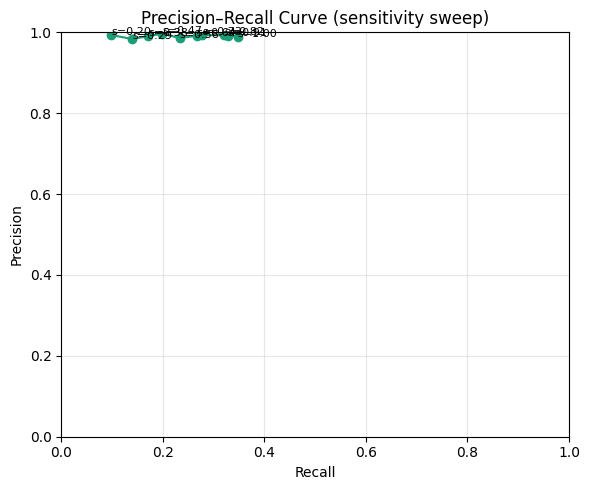


[Best F1 across sweep]  F1=0.514  |  Precision=0.990  |  Recall=0.347  |  sensitivity s=1.00


In [ ]:

# Phase-4C (Standalone, Fixed): False Positives + Precision/Recall + F1


import os
import random
import math
import matplotlib.pyplot as plt


# Ensure results/ folder exists

os.makedirs("results", exist_ok=True)


_required_from_phase3 = [
    "build_enterprise_twin",
    "assign_monitor_costs",
    "monte_carlo_attack_stats",
    "cost_aware_candidates",
    "evaluate_detection_rate",
    "simulate_single_attack",
    "MAX_STEPS_LARGE",
    "ATTACKER_MODE",
    "FAST_DEMO",
    "P_DETECT_ON_IDS",
]
_missing = [r for r in _required_from_phase3 if r not in globals()]
if _missing:
    raise RuntimeError(
        f"Phase-4C requires Phase-3 to be run first.\n"
        f"Missing globals: {_missing}\n"
        f"Please run the Phase-3 cell before running this cell."
    )
print("[Phase-4C] All Phase-3 dependencies confirmed. Proceeding.")


# Phase-4C local parameters

P_FALSE_ALARM_BASE = 0.01          # base false-alarm prob per IDS node visit (benign)
P_DETECT_BASE      = P_DETECT_ON_IDS   # reuse Phase-3 imperfect detection constant


# Benign walk simulator
# -------------------------
def simulate_benign_walk(G, max_steps: int = 40):

    if G.number_of_nodes() == 0:
        return []
    start   = random.choice(list(G.nodes()))
    current = start
    path    = [current]
    steps   = 0
    while steps < max_steps:
        succ = list(G.successors(current))
        if not succ:
            break
        current = random.choice(succ)
        path.append(current)
        steps += 1
    return path


# Precision / Recall / F1 evaluator

def evaluate_precision_recall(
    G, src, tgt, ids_nodes: set,
    n_attacks: int = 3000,
    n_benign:  int = 3000,
    max_steps_attack: int = 50,
    max_steps_benign: int = 40,
    p_detect_base: float = P_DETECT_BASE,
    p_fa_base:     float = P_FALSE_ALARM_BASE,
    attacker_mode: str   = ATTACKER_MODE,
    sens: float = 1.0    # FIX: named 'sens', never 's', to avoid any collision
):

    if not ids_nodes:
        return 0.0, 0.0, 0.0

    # Intersect with current graph nodes (safe after any removals)
    ids_nodes = set(ids_nodes) & set(G.nodes())
    if not ids_nodes:
        return 0.0, 0.0, 0.0

    # Effective probabilities under this sensitivity level
    sens         = float(max(0.0, min(1.0, sens)))
    p_detect_eff = min(1.0, max(0.0, sens * float(p_detect_base)))
    p_fa_eff     = min(1.0, max(0.0, sens * float(p_fa_base)))

    # --- Attack trials (TP / FN) ---
    TP = 0
    FN = 0
    for _ in range(n_attacks):

        ok, path = simulate_single_attack(
            G, src, tgt,
            mode=attacker_mode,
            max_steps=max_steps_attack
        )
        detected = any(
            (nd in ids_nodes) and (random.random() <= p_detect_eff)
            for nd in path
        )
        if detected:
            TP += 1
        else:
            FN += 1

    # --- Benign trials (FP / TN) ---
    FP = 0
    TN = 0
    for _ in range(n_benign):
        path_b = simulate_benign_walk(G, max_steps=max_steps_benign)
        if any(
            (nd in ids_nodes) and (random.random() <= p_fa_eff)
            for nd in path_b
        ):
            FP += 1
        else:
            TN += 1

    # Metrics — guard against division by zero
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1        = (2 * precision * recall) / (precision + recall) \
                if (precision + recall) > 0 else 0.0
    return precision, recall, f1


# PR curve plotter

def plot_precision_recall_curve(
    G, src, tgt, ids_nodes: set,
    attacker_mode: str = ATTACKER_MODE,
    n_points:  int = 8,
    n_attacks: int = 2500,
    n_benign:  int = 2500,
    save_path: str = "results/phase4c_precision_recall_curve.png"  # FIX: default save path
):

    ids_nodes = set(ids_nodes) & set(G.nodes())
    if not ids_nodes:
        print("No IDS nodes in graph -> cannot compute PR curve.")
        return

    # Build sweep values: n_points evenly spaced from 0.2 to 1.0
    S_vals = [0.2 + i * (0.8 / max(1, n_points - 1)) for i in range(n_points)]
    PR     = []
    best   = (0.0, 0.0, 0.0, 0.0)   # (F1, Precision, Recall, sens)

    for sens_val in S_vals:
        P, R, F1 = evaluate_precision_recall(
            G, src, tgt, ids_nodes,
            n_attacks=n_attacks,
            n_benign=n_benign,
            attacker_mode=attacker_mode,
            sens=sens_val
        )
        PR.append((P, R, F1, sens_val))
        if F1 > best[0]:
            best = (F1, P, R, sens_val)


    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(
        [r for (_, r, _, _) in PR],
        [p for (p, _, _, _) in PR],
        marker="o", color="#1b9e77"
    )
    for (P, R, F1, sens_val) in PR:
        ax.text(R, P, f"s={sens_val:.2f}", fontsize=8)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title("Precision–Recall Curve (sensitivity sweep)")
    ax.grid(True, alpha=0.3)
    fig.tight_layout()


    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
        print(f"  [Saved] {save_path}")
    plt.show()

    print(f"\n[Best F1 across sweep]"
          f"  F1={best[0]:.3f}"
          f"  |  Precision={best[1]:.3f}"
          f"  |  Recall={best[2]:.3f}"
          f"  |  sensitivity s={best[3]:.2f}")

    return PR, best


def run_phase4C_demo(attacker_mode: str = ATTACKER_MODE):
    print("\n=== Phase-4C: False Positives + Precision/Recall + F1 ===")

    # 1) Build enterprise twin and assign costs

    G, src, tgt, _ = build_enterprise_twin()
    assign_monitor_costs(G)

    # 2) Monte Carlo risk scoring for IDS placement
    risk, sr, _, mc_time = monte_carlo_attack_stats(
        G, src, tgt,
        n_sims=3000 if FAST_DEMO else 6000,
        max_steps=MAX_STEPS_LARGE,
        attacker_mode=attacker_mode
    )
    print(f"  Monte Carlo done: success_rate={sr:.3f} | time={mc_time:.2f}s")

    # 3) Risk-aware placement at 5% cost budget
    eligible   = [nd for nd in G.nodes() if nd not in {src, tgt}]
    total_cost = sum(G.nodes[nd]["monitor_cost"] for nd in eligible) if eligible else 0.0
    B          = 0.05 * total_cost if total_cost > 0 else 0.0

    if B <= 0:
        print("  Total eligible cost is 0 — cannot select IDS nodes. Check assign_monitor_costs.")
        return

    cand_sets = cost_aware_candidates(G, risk, exclude={src, tgt}, budget=B)
    ids_nodes = cand_sets.get("Risk-aware", set())

    print(f"  Attacker mode={attacker_mode}"
          f"  |  IDS nodes chosen={len(ids_nodes)}"
          f"  |  budget (5%)={B:,.0f}")

    if not ids_nodes:
        print("  No IDS nodes selected -> cannot compute PR curve."
              " Try increasing budget_pct or checking monitor costs.")
        return

    # 4) Compute and plot the PR curve

    plot_precision_recall_curve(
        G, src, tgt, ids_nodes,
        attacker_mode=attacker_mode,
        n_points  = 7  if FAST_DEMO else 10,
        n_attacks = 1500 if FAST_DEMO else 3000,
        n_benign  = 1500 if FAST_DEMO else 3000,
        save_path = "results/phase4c_precision_recall_curve.png"   # FIX: saved
    )


run_phase4C_demo(attacker_mode=ATTACKER_MODE)

[Phase-4D] All Phase-3 dependencies confirmed. Proceeding.

=== Phase-4D: Stackelberg Best-Response (Worst-Case Attacker) ===

[Enterprise] Network Stats
Nodes: 235 | Edges: 769 | Avg degree: 6.54
Attacker node: inet_0 | Target node: db_0

Computing risk scores via Monte Carlo...
  Success rate: 0.017 | time: 0.19s
  Total eligible monitor cost: 566,360

--- Budget = 5.0% (28,318) ---

Strategy           Worst-Case Det    Best-Response Mode  |  Per-mode detections
------------------------------------------------------------------------------------------------
Risk-aware                  0.302              stealthy  |  mpp:0.45, stealthy:0.30, noisy:0.39, random:0.35
Degree                      0.192              stealthy  |  mpp:0.37, stealthy:0.19, noisy:0.20, random:0.20
Betweenness                 0.163              stealthy  |  mpp:0.36, stealthy:0.16, noisy:0.22, random:0.20
PageRank                    0.000                   mpp  |  mpp:0.00, stealthy:0.06, noisy:0.08, random:0.0

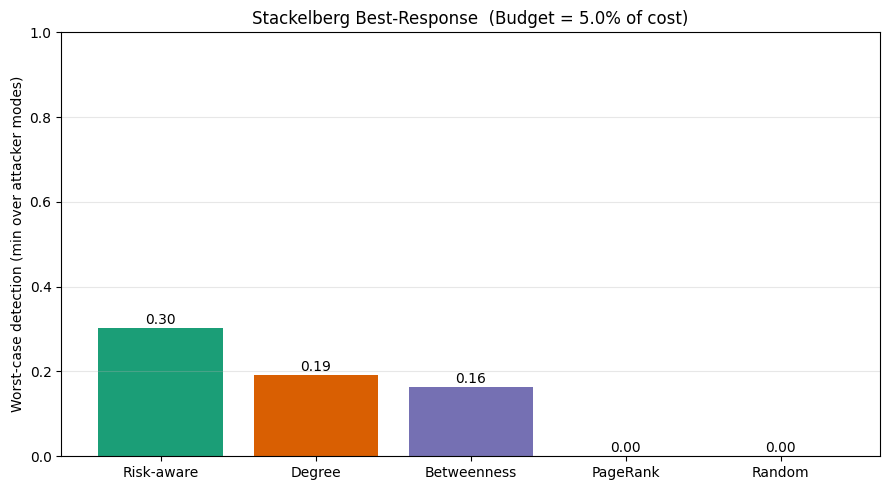

In [ ]:

# Phase-4D (Patched): Stackelberg Best-Response (Worst-Case Detection)

import os
import matplotlib.pyplot as plt


os.makedirs("results", exist_ok=True)


_required_from_phase3 = [
    "build_enterprise_twin",
    "assign_monitor_costs",
    "monte_carlo_attack_stats",
    "evaluate_detection_rate",
    "cost_aware_candidates",
    "print_network_stats",
    "MAX_STEPS_LARGE",
    "P_DETECT_ON_IDS",
    "ATTACKER_MODE",
    "FAST_DEMO",
]
_missing = [r for r in _required_from_phase3 if r not in globals()]
if _missing:
    raise RuntimeError(
        f"Phase-4D requires Phase-3 to be run first.\n"
        f"Missing globals: {_missing}\n"
        f"Please run the Phase-3 cell before running this cell."
    )
print("[Phase-4D] All Phase-3 dependencies confirmed. Proceeding.")


BR_ATTACKER_SET = ["mpp", "stealthy", "noisy", "random"]


def _placements_for_budget(
    G, risk_scores: dict, exclude: set, budget: float,
    use_knapsack:    bool = True,
    knap_unit:       int  = 100,
    knap_max_states: int  = 2_000_000
) -> dict:

    if budget <= 0:
        return {k: set() for k in
                ["Risk-aware", "Degree", "Betweenness", "PageRank", "Random"]}

    has_knapsack = use_knapsack and ("cost_aware_candidates_with_knapsack" in globals())

    if has_knapsack:
        placements = cost_aware_candidates_with_knapsack(   # defined in Phase-4E
            G, risk_scores,
            exclude=exclude, budget=budget,
            unit=knap_unit, max_states=knap_max_states
        )
    else:
        placements = cost_aware_candidates(G, risk_scores, exclude=exclude, budget=budget)

    # Build ordered key list — Knapsack first when present
    expected = ["Risk-aware", "Degree", "Betweenness", "PageRank", "Random"]
    if has_knapsack:
        expected = ["Knapsack-Exact"] + expected

    # Intersect each set with current graph nodes for safety
    V   = set(G.nodes())
    out = {}
    for key in expected:
        out[key] = placements.get(key, set()) & V
    return out


# Best-response (worst-case) evaluator

def _best_response_detection(
    G, src, tgt, ids_nodes: set,
    attacker_modes: list = None,
    n_sims:    int   = 4000,
    max_steps: int   = 50,
    p_detect:  float = 0.95
):

    ids_nodes = set(ids_nodes) & set(G.nodes())
    if not attacker_modes:
        attacker_modes = ["mpp", "stealthy", "noisy", "random"]

    det_per_mode = {}
    for mode in attacker_modes:
        det, _ = evaluate_detection_rate(
            G, src, tgt, ids_nodes,
            n_sims=max(1, n_sims),
            max_steps=max_steps,
            attacker_mode=mode,
            p_detect=p_detect
        )
        det_per_mode[mode] = det

    worst_mode = (min(det_per_mode, key=lambda m: det_per_mode[m])
                  if det_per_mode else None)
    worst_det  = det_per_mode.get(worst_mode, 0.0) if worst_mode is not None else 0.0
    return worst_det, worst_mode, det_per_mode

# Phase-4D orchestrator

def run_phase4D(
    attacker_modes:  list  = None,
    budget_pct_list: list  = None,
    n_sims_risk: int   = 3000 if globals().get("FAST_DEMO", False) else 6000,
    n_sims_br:   int   = 2500 if globals().get("FAST_DEMO", False) else 4000,
    use_knapsack:    bool  = True,
    knap_unit:       int   = 100,
    knap_max_states: int   = 2_000_000
):

    print("\n=== Phase-4D: Stackelberg Best-Response (Worst-Case Attacker) ===")

    if attacker_modes is None:
        attacker_modes = BR_ATTACKER_SET
    if budget_pct_list is None:
        budget_pct_list = [0.05]   # default: 5% of total eligible cost


    # 1) Build twin and assign monitoring costs

    G, src, tgt, _ = build_enterprise_twin()
    assign_monitor_costs(G)
    print_network_stats(G, "[Enterprise] Network Stats")
    print(f"Attacker node: {src} | Target node: {tgt}")


    # 2) Monte Carlo risk scoring

    print("\nComputing risk scores via Monte Carlo...")
    risk, succ_rate, _, mc_time = monte_carlo_attack_stats(
        G, src, tgt,
        n_sims=n_sims_risk,
        max_steps=MAX_STEPS_LARGE,
        attacker_mode=ATTACKER_MODE
    )
    print(f"  Success rate: {succ_rate:.3f} | time: {mc_time:.2f}s")

    eligible   = [nd for nd in G.nodes() if nd not in {src, tgt}]
    total_cost = sum(G.nodes[nd]["monitor_cost"] for nd in eligible) if eligible else 0.0
    print(f"  Total eligible monitor cost: {total_cost:,.0f}")

    if total_cost <= 0:
        print("No eligible nodes for IDS budget; cannot run Phase-4D.")
        return


    # 3) Evaluate worst-case detection for each strategy and budget level

    for Bpct in budget_pct_list:
        B = Bpct * total_cost
        print(f"\n--- Budget = {Bpct*100:.1f}% ({B:,.0f}) ---")

        placements = _placements_for_budget(
            G, risk_scores=risk, exclude={src, tgt}, budget=B,
            use_knapsack=use_knapsack,
            knap_unit=knap_unit,
            knap_max_states=knap_max_states
        )

        # Ordered strategy list — Knapsack first if present
        strategies_order = [
            "Knapsack-Exact", "Risk-aware", "Degree",
            "Betweenness", "PageRank", "Random"
        ]

        strategies = [strat for strat in strategies_order if strat in placements]

        # Compute worst-case detection per strategy
        worst_results = {}   # strat -> (worst_det, worst_mode, det_per_mode)
        for strat in strategies:
            ids_nodes = placements.get(strat, set())
            worst_det, worst_mode, det_per_mode = _best_response_detection(
                G, src, tgt, ids_nodes,
                attacker_modes=attacker_modes,
                n_sims=n_sims_br,
                max_steps=MAX_STEPS_LARGE,
                p_detect=P_DETECT_ON_IDS
            )
            worst_results[strat] = (worst_det, worst_mode, det_per_mode)

        # Console summary table
        print(f"\n{'Strategy':<16} {'Worst-Case Det':>16}  "
              f"{'Best-Response Mode':>20}  |  Per-mode detections")
        print("-" * 96)
        for strat in strategies:
            wd, wm, dets = worst_results.get(strat, (0.0, None, {}))
            dets_str = ", ".join(
                [f"{m}:{dets.get(m, 0.0):.2f}" for m in attacker_modes]
            )
            print(f"{strat:<16} {wd:16.3f}  {str(wm):>20}  |  {dets_str}")


        vals   = [worst_results.get(strat, (0.0, None, {}))[0] for strat in strategies]
        colors = ["#1b9e77","#d95f02","#7570b3",
                  "#66a61e","#e7298a","#a6761d"][:len(strategies)]

        fig, ax = plt.subplots(figsize=(9, 5))
        bars = ax.bar(strategies, vals, color=colors)
        for b, v in zip(bars, vals):
            ax.text(
                b.get_x() + b.get_width() / 2,
                v + 0.01, f"{v:.2f}",
                ha="center", fontsize=10
            )
        ax.set_ylim(0, 1.0)
        ax.set_ylabel("Worst-case detection (min over attacker modes)")
        ax.set_title(f"Stackelberg Best-Response  (Budget = {Bpct*100:.1f}% of cost)")
        ax.grid(True, axis="y", alpha=0.3)
        fig.tight_layout()


        save_path = f"results/phase4d_stackelberg_budget_{int(Bpct*100)}pct.png"
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
        print(f"  [Saved] {save_path}")
        plt.show()

.
run_phase4D(
    attacker_modes  = ["mpp", "stealthy", "noisy", "random"],
    budget_pct_list = [0.05],        # try [0.02, 0.05, 0.10] for multiple budgets
    use_knapsack    = True,          # set False to skip Knapsack-Exact
    knap_unit       = 100,           # cost discretisation unit (hundreds)
    knap_max_states = 2_000_000      # DP safety bound
)

In [ ]:

# Phase-4E: Exact Knapsack DP for IDS Placement

import os


os.makedirs("results", exist_ok=True)


_required_from_phase3 = [
    "cost_aware_candidates",
    "cost_aware_select_by_ratio",
]
_missing = [r for r in _required_from_phase3 if r not in globals()]
if _missing:
    raise RuntimeError(
        f"Phase-4E requires Phase-3 to be run first.\n"
        f"Missing globals: {_missing}\n"
        f"Please run the Phase-3 cell before running this cell."
    )
print("[Phase-4E] All Phase-3 dependencies confirmed. Proceeding.")


def knapsack_exact_dp(
    items:       list,   # list of (node, value, cost_int)  — cost already in units
    budget_int:  int,    # integer capacity (budget // unit)
    unit:        int = 100,
    max_states:  int = 2_000_000
):
    """
    Solve the 0/1 knapsack exactly via DP with traceback.

    items      : [(node, value, cost_int), ...]  where cost_int = raw_cost // unit
    budget_int : integer capacity W = budget // unit
    max_states : safety guard — if n * W > max_states, fall back to greedy ratio
                 to avoid allocating an enormous DP table.

    Returns a set of node names.
    """
    n = len(items)
    W = budget_int

    if n == 0 or W <= 0:
        return set()

    # Safety guard: fall back to greedy if DP table would be too large
    if n * W > max_states:
        items_sorted = sorted(items, key=lambda x: x[1] / max(x[2], 1), reverse=True)
        chosen = set()
        spend  = 0
        for node, val, cost_int in items_sorted:
            if spend + cost_int <= W:
                chosen.add(node)
                spend += cost_int
        return chosen

    # Standard 0/1 DP (value maximisation)
    # dp[w] = best total value achievable with capacity w
    dp   = [0.0] * (W + 1)
    keep = [[False] * (W + 1) for _ in range(n)]

    for i, (node, val, cost_int) in enumerate(items):
        # Traverse capacity in reverse to ensure each item used at most once
        for w in range(W, cost_int - 1, -1):
            candidate = dp[w - cost_int] + val
            if candidate > dp[w]:
                dp[w]    = candidate
                keep[i][w] = True

    # Traceback to recover selected items
    chosen = set()
    w = W
    for i in range(n - 1, -1, -1):
        if keep[i][w]:
            chosen.add(items[i][0])
            w -= items[i][2]   # subtract this item's cost_int
    return chosen

# Wrapper: handles discretisation and excludes

def cost_aware_select_knapsack_exact_or_greedy(
    scores:     dict,
    costs:      dict,
    budget:     float,
    exclude:    set,
    unit:       int = 100,
    max_states: int = 2_000_000
) -> set:

    # Build item list, excluding forbidden nodes and zero/huge costs
    items_raw = [
        (nd, float(scores.get(nd, 0.0)), float(costs.get(nd, 999999)))
        for nd in scores
        if nd not in exclude and 0 < costs.get(nd, 0) < 1e8
    ]

    budget_int = max(1, int(budget // unit))

    # Discretise costs — at least 1 unit each
    items_int = [
        (nd, val, max(1, int(cost // unit)))
        for nd, val, cost in items_raw
    ]

    return knapsack_exact_dp(items_int, budget_int, unit=unit, max_states=max_states)


# Public API: extends cost_aware_candidates with "Knapsack-Exact"
# This is what Phase-4D checks for in globals()

def cost_aware_candidates_with_knapsack(
    G,
    ranking_scores: dict,
    exclude:        set,
    budget:         float,
    unit:           int = 100,
    max_states:     int = 2_000_000
) -> dict:

    # Start with the standard 5 baselines (Risk-aware, Degree, etc.)
    base = cost_aware_candidates(G, ranking_scores, exclude, budget)

    # Compute exact knapsack on risk scores
    costs = {nd: G.nodes[nd].get("monitor_cost", 999999) for nd in G.nodes()}
    base["Knapsack-Exact"] = cost_aware_select_knapsack_exact_or_greedy(
        ranking_scores, costs, budget, exclude,
        unit=unit, max_states=max_states
    )
    return base

print("[Phase-4E] Functions defined:")
print("  knapsack_exact_dp")
print("  cost_aware_select_knapsack_exact_or_greedy")
print("  cost_aware_candidates_with_knapsack  <- Phase-4D picks this up automatically")

[Phase-4E] All Phase-3 dependencies confirmed. Proceeding.
[Phase-4E] Functions defined:
  knapsack_exact_dp
  cost_aware_select_knapsack_exact_or_greedy
  cost_aware_candidates_with_knapsack  <- Phase-4D picks this up automatically


[Phase-4F] All Phase-3 dependencies confirmed. Proceeding.

=== Phase-4F: Scalability Benchmark (with Memory Tracking) ===
N=  100 | sims=1050 | success_rate=0.031 | det=0.238 | time=0.05s | ΔRSS≈0.0 MB
N=  500 | sims=1250 | success_rate=0.005 | det=0.406 | time=0.57s | ΔRSS≈0.0 MB
N= 1000 | sims=1500 | success_rate=0.004 | det=0.549 | time=0.71s | ΔRSS≈0.0 MB
N= 5000 | sims=3500 | success_rate=0.001 | det=0.122 | time=5.28s | ΔRSS≈0.0 MB
N=10000 | sims=4000 | success_rate=0.001 | det=0.092 | time=12.54s | ΔRSS≈4.3 MB

  [Saved] results/scalability_runtime_memory.csv
  [Saved] results/scalability_runtime.png


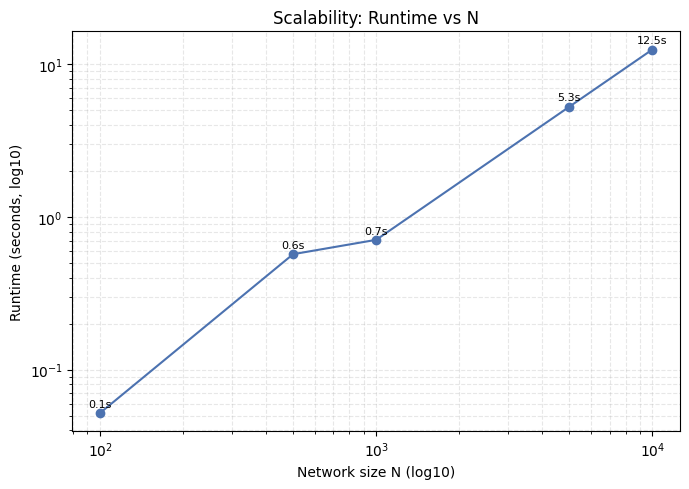

  [Saved] results/scalability_memory.png


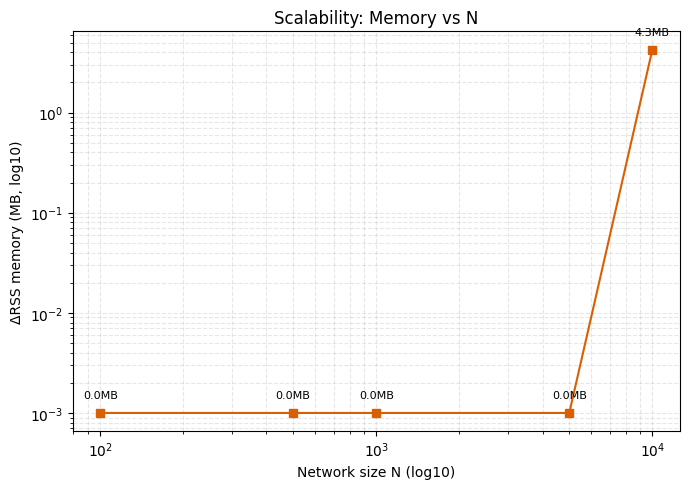

([100, 500, 1000, 5000, 10000],
 [0.05204033851623535,
  0.5713012218475342,
  0.7095630168914795,
  5.283716917037964,
  12.53749680519104],
 [0.0, 0.0, 0.0, 0.0, 4.2578125])

In [ ]:

# Phase-4F: Memory Usage in Scalability Benchmark + CSV export


import os
import csv
import time
import math
import matplotlib.pyplot as plt


os.makedirs("results", exist_ok=True)


_required_from_phase3 = [
    "proportional_sizes",
    "build_enterprise_twin",
    "assign_monitor_costs",
    "monte_carlo_attack_stats",
    "cost_aware_candidates",
    "evaluate_detection_rate",
    "MAX_STEPS_LARGE",
    "ATTACKER_MODE",
]
_missing = [r for r in _required_from_phase3 if r not in globals()]
if _missing:
    raise RuntimeError(
        f"Phase-4F requires Phase-3 to be run first.\n"
        f"Missing globals: {_missing}\n"
        f"Please run the Phase-3 cell before running this cell."
    )
print("[Phase-4F] All Phase-3 dependencies confirmed. Proceeding.")


try:
    import psutil
    _PSUTIL_OK = True
except Exception:
    _PSUTIL_OK = False
    print("[Phase-4F] psutil not available — memory column will be NaN.")

def get_rss_mb() -> float:
    """Return current process RSS in MB, or NaN if psutil is unavailable."""
    if not _PSUTIL_OK:
        return float("nan")
    process = psutil.Process()
    return process.memory_info().rss / (1024.0 * 1024.0)


# Scalability benchmark with memory tracking

def scalability_benchmark_with_memory(
    N_list:        list = None,
    attacker_mode: str  = ATTACKER_MODE
):
    if N_list is None:
        N_list = [100, 500, 1000, 5000, 10000]

    print("\n=== Phase-4F: Scalability Benchmark (with Memory Tracking) ===")
    runtimes = []
    memories = []
    Ns       = []

    for N in N_list:
        sizes = proportional_sizes(N)


        G, src, tgt, _ = build_enterprise_twin(sizes=sizes)
        assign_monitor_costs(G)

        # Scale simulation count modestly with N to bound total wall time
        sims = min(4000, 1000 + max(0, N) // 2)

        mem_before = get_rss_mb()
        t0         = time.time()

        # Risk scoring
        risk, sr, _, _ = monte_carlo_attack_stats(
            G, src, tgt,
            n_sims=sims,
            max_steps=MAX_STEPS_LARGE,
            attacker_mode=attacker_mode
        )

        # IDS placement at 5% of eligible cost
        eligible = [nd for nd in G.nodes() if nd not in {src, tgt}]
        B        = 0.05 * sum(G.nodes[nd]["monitor_cost"] for nd in eligible) if eligible else 0.0
        ids      = (cost_aware_candidates(G, risk, exclude={src, tgt}, budget=B)["Risk-aware"]
                    if B > 0 else set())

        # Detection rate
        det, _ = evaluate_detection_rate(
            G, src, tgt, ids,
            n_sims=min(2000, max(1, sims // 2)),
            max_steps=MAX_STEPS_LARGE,
            attacker_mode=attacker_mode
        )

        t1         = time.time()
        mem_after  = get_rss_mb()

        rt        = t1 - t0
        mem_delta = (mem_after - mem_before) if _PSUTIL_OK else float("nan")

        Ns.append(N)
        runtimes.append(rt)
        memories.append(max(0.0, mem_delta) if not math.isnan(mem_delta) else float("nan"))

        print(f"N={N:5d} | sims={sims:4d} | success_rate={sr:.3f}"
              f" | det={det:.3f} | time={rt:.2f}s | ΔRSS≈{mem_delta:.1f} MB")


    # CSV export

    csv_path = "results/scalability_runtime_memory.csv"
    with open(csv_path, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["N", "runtime_seconds", "delta_rss_MB"])
        for N, rt, mb in zip(Ns, runtimes, memories):
            w.writerow([N, round(rt, 4), round(mb, 4) if not math.isnan(mb) else "nan"])
    print(f"\n  [Saved] {csv_path}")


    # Runtime log-log plot

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.loglog(Ns, runtimes, marker="o")
    ax.set_xscale("log", base=10)
    ax.set_yscale("log", base=10)
    for x, y in zip(Ns, runtimes):
        ax.text(x, y * 1.1, f"{y:.1f}s", ha="center", fontsize=8)
    ax.set_xlabel("Network size N (log10)")
    ax.set_ylabel("Runtime (seconds, log10)")
    ax.set_title("Scalability: Runtime vs N")
    ax.grid(True, which="both", ls="--", alpha=0.3)
    fig.tight_layout()
    fig.savefig("results/scalability_runtime.png", dpi=200, bbox_inches="tight")
    print("  [Saved] results/scalability_runtime.png")
    plt.show()


    # Memory log-log plot

    mem_plot = [
        max(m, 1e-3) if (not math.isnan(m)) else 1e-3
        for m in memories
    ]
    fig2, ax2 = plt.subplots(figsize=(7, 5))
    ax2.loglog(Ns, mem_plot, marker="s", color="#d95f02")
    ax2.set_xscale("log", base=10)
    ax2.set_yscale("log", base=10)
    for x, y_raw, y_plot in zip(Ns, memories, mem_plot):
        label = f"{y_raw:.1f}MB" if not math.isnan(y_raw) else "nan"
        ax2.text(x, y_plot * 1.4, label, ha="center", fontsize=8)
    ax2.set_xlabel("Network size N (log10)")
    ax2.set_ylabel("ΔRSS memory (MB, log10)")
    ax2.set_title("Scalability: Memory vs N")
    ax2.grid(True, which="both", ls="--", alpha=0.3)
    fig2.tight_layout()
    fig2.savefig("results/scalability_memory.png", dpi=200, bbox_inches="tight")
    print("  [Saved] results/scalability_memory.png")
    plt.show()

    return Ns, runtimes, memories


scalability_benchmark_with_memory(
    N_list        = [100, 500, 1000, 5000, 10000],
    attacker_mode = ATTACKER_MODE   # swap to "mpp", "stealthy", "noisy" as needed
)

[Phase-4G] All Phase-3 dependencies confirmed. Proceeding.

=== Phase-4G: Attacker Skill Sweep ===
  Budget: 5.0%  (28,318)  |  IDS nodes selected: 16

  Attacker       Detection
  --------------------------
  random             0.342
  mpp                0.469
  stealthy           0.308
  noisy              0.391

  [Saved] results/phase4g_skill_sweep_budget_5pct.png


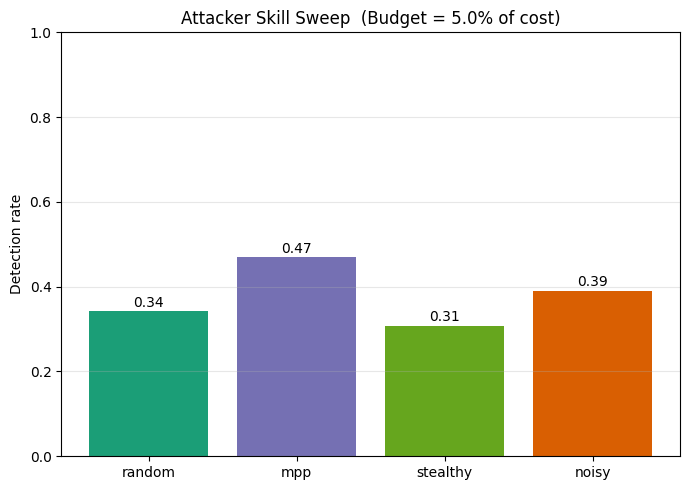

{'random': 0.3424, 'mpp': 0.4694, 'stealthy': 0.3084, 'noisy': 0.391}

In [ ]:

# Phase-4G: Attacker Skill Sweep (random / mpp / stealthy / noisy)

import os
import matplotlib.pyplot as plt


os.makedirs("results", exist_ok=True)


_required_from_phase3 = [
    "build_enterprise_twin",
    "assign_monitor_costs",
    "monte_carlo_attack_stats",
    "cost_aware_candidates",
    "evaluate_detection_rate",
    "MAX_STEPS_LARGE",
    "FAST_DEMO",
]
_missing = [r for r in _required_from_phase3 if r not in globals()]
if _missing:
    raise RuntimeError(
        f"Phase-4G requires Phase-3 to be run first.\n"
        f"Missing globals: {_missing}\n"
        f"Please run the Phase-3 cell before running this cell."
    )
print("[Phase-4G] All Phase-3 dependencies confirmed. Proceeding.")


# Attacker skill sweep

def attacker_skill_sweep(
    attacker_modes: list  = None,
    budget_pct:     float = 0.05,
    sims:           int   = 3000 if globals().get("FAST_DEMO", False) else 5000
):
    print("\n=== Phase-4G: Attacker Skill Sweep ===")
    if attacker_modes is None:
        attacker_modes = ["random", "mpp", "stealthy", "noisy"]


    # 1) Build twin and assign monitoring costs

    G, src, tgt, _ = build_enterprise_twin()
    assign_monitor_costs(G)


    # 2) Monte Carlo risk scoring under "random" attacker for placement
    #    (placement is fixed; only evaluation mode changes)

    risk, sr, _, _ = monte_carlo_attack_stats(
        G, src, tgt,
        n_sims=3000 if globals().get("FAST_DEMO", False) else 6000,
        max_steps=MAX_STEPS_LARGE,
        attacker_mode="random"
    )


    # 3) Risk-aware IDS placement at fixed monetary budget

    eligible   = [nd for nd in G.nodes() if nd not in {src, tgt}]
    total_cost = sum(G.nodes[nd]["monitor_cost"] for nd in eligible) if eligible else 0.0
    B          = budget_pct * total_cost if total_cost > 0 else 0.0

    if B <= 0:
        print("  Total eligible cost is 0 — cannot select IDS nodes.")
        return

    ids_nodes = cost_aware_candidates(
        G, risk, exclude={src, tgt}, budget=B
    )["Risk-aware"]

    print(f"  Budget: {budget_pct*100:.1f}%  ({B:,.0f})"
          f"  |  IDS nodes selected: {len(ids_nodes)}")

    if not ids_nodes:
        print("  No IDS nodes selected — try a larger budget_pct.")
        return


    # 4) Evaluate detection across all attacker modes

    dets = {}
    for mode in attacker_modes:
        det, _ = evaluate_detection_rate(
            G, src, tgt, ids_nodes,
            n_sims=sims,
            max_steps=MAX_STEPS_LARGE,
            attacker_mode=mode
        )
        dets[mode] = det


    # 5) Console summary table

    print(f"\n  {'Attacker':<12}  {'Detection':>10}")
    print("  " + "-" * 26)
    for mode in attacker_modes:
        print(f"  {mode:<12}  {dets[mode]:10.3f}")


    # 6) Bar chart

    vals   = [dets[mode] for mode in attacker_modes]
    colors = ["#1b9e77", "#7570b3", "#66a61e", "#d95f02"][:len(attacker_modes)]

    fig, ax = plt.subplots(figsize=(7, 5))
    bars = ax.bar(attacker_modes, vals, color=colors)
    for b, v in zip(bars, vals):
        ax.text(
            b.get_x() + b.get_width() / 2,
            v + 0.01, f"{v:.2f}",
            ha="center", fontsize=10
        )
    ax.set_ylim(0, 1.0)
    ax.set_ylabel("Detection rate")
    ax.set_title(f"Attacker Skill Sweep  (Budget = {budget_pct*100:.1f}% of cost)")
    ax.grid(True, axis="y", alpha=0.3)
    fig.tight_layout()

    # FIX: save before show — filename encodes budget %
    save_path = f"results/phase4g_skill_sweep_budget_{int(budget_pct*100)}pct.png"
    fig.savefig(save_path, dpi=200, bbox_inches="tight")
    print(f"\n  [Saved] {save_path}")
    plt.show()

    return dets


# Entry point

attacker_skill_sweep(
    attacker_modes = ["random", "mpp", "stealthy", "noisy"],
    budget_pct     = 0.05
)